/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/1822817783.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cleaned_data['Year'] = pd.to_datetime(cleaned_data['Time Period Start Date']).dt.year
/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/1822817783.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Year'] = pd.to_datetime(cleaned_data['Time Period Start Date']).dt.year


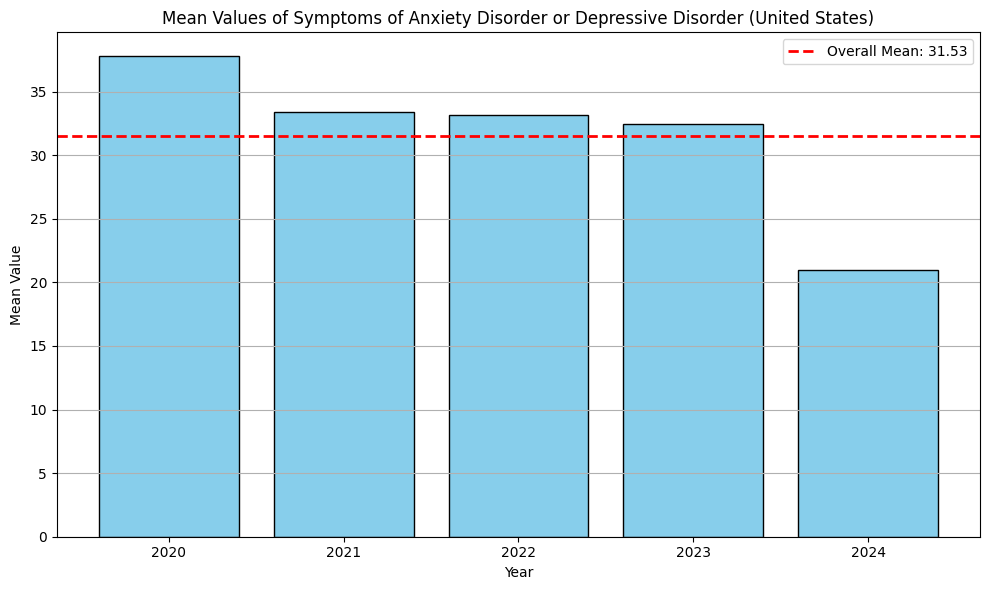

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder" and "United States"
filtered_data = depression_data[
    (depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder') &
    (depression_data['Subgroup'] == 'United States')
]

# Drop rows with missing values in the 'Value' column
cleaned_data = filtered_data.dropna(subset=['Value'])

# Extract the year from the 'Time Period Start Date' for grouping
cleaned_data['Year'] = pd.to_datetime(cleaned_data['Time Period Start Date']).dt.year

# Calculate the mean value for each year
mean_values_by_year = cleaned_data.groupby('Year')['Value'].mean().reset_index()

# Calculate the overall mean value
overall_mean = mean_values_by_year['Value'].mean()

# Create a bar plot for the mean values by year with a visible overall mean line
plt.figure(figsize=(10, 6))
plt.bar(mean_values_by_year['Year'], mean_values_by_year['Value'], color='skyblue', edgecolor='black')
plt.axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder (United States)')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend()
plt.grid(axis='y')
plt.xticks(mean_values_by_year['Year'])  # Ensure all years are shown on the x-axis
plt.tight_layout()
plt.show()

# Export the cleaned data to a new CSV file for use in Tableau
output_path = 'Cleaned_Corrected_Depression_Symptoms.csv'
mean_values_by_year.to_csv(output_path, index=False)



<Axes: xlabel='Time Period Start Date'>

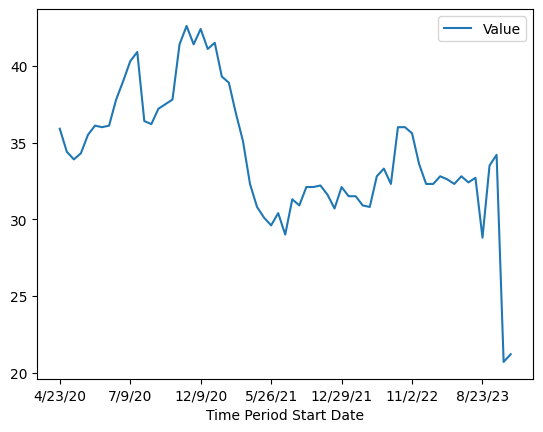

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the newly uploaded data from the corrected CSV file
new_file_path = 'Depression_Symptoms.csv'
depression_data = pd.read_csv(new_file_path)


us_data = depression_data.drop(depression_data[depression_data['State'] != 'United States'].index)

us_data = us_data.drop(us_data[us_data['Subgroup'] != 'United States'].index)

us_data = us_data.drop(us_data[us_data['Indicator'] != 'Symptoms of Anxiety Disorder or Depressive Disorder'].index)


us_data = us_data.drop("Quartile Range", axis='columns')


us_data = us_data.dropna()

us_data.head()

us_data.plot(x="Time Period Start Date", y="Value")


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/4254991364.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cleaned_data['Year'] = pd.to_datetime(cleaned_data['Time Period Start Date']).dt.year
/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/4254991364.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Year'] = pd.to_datetime(cleaned_data['Time Period Start Date']).dt.year


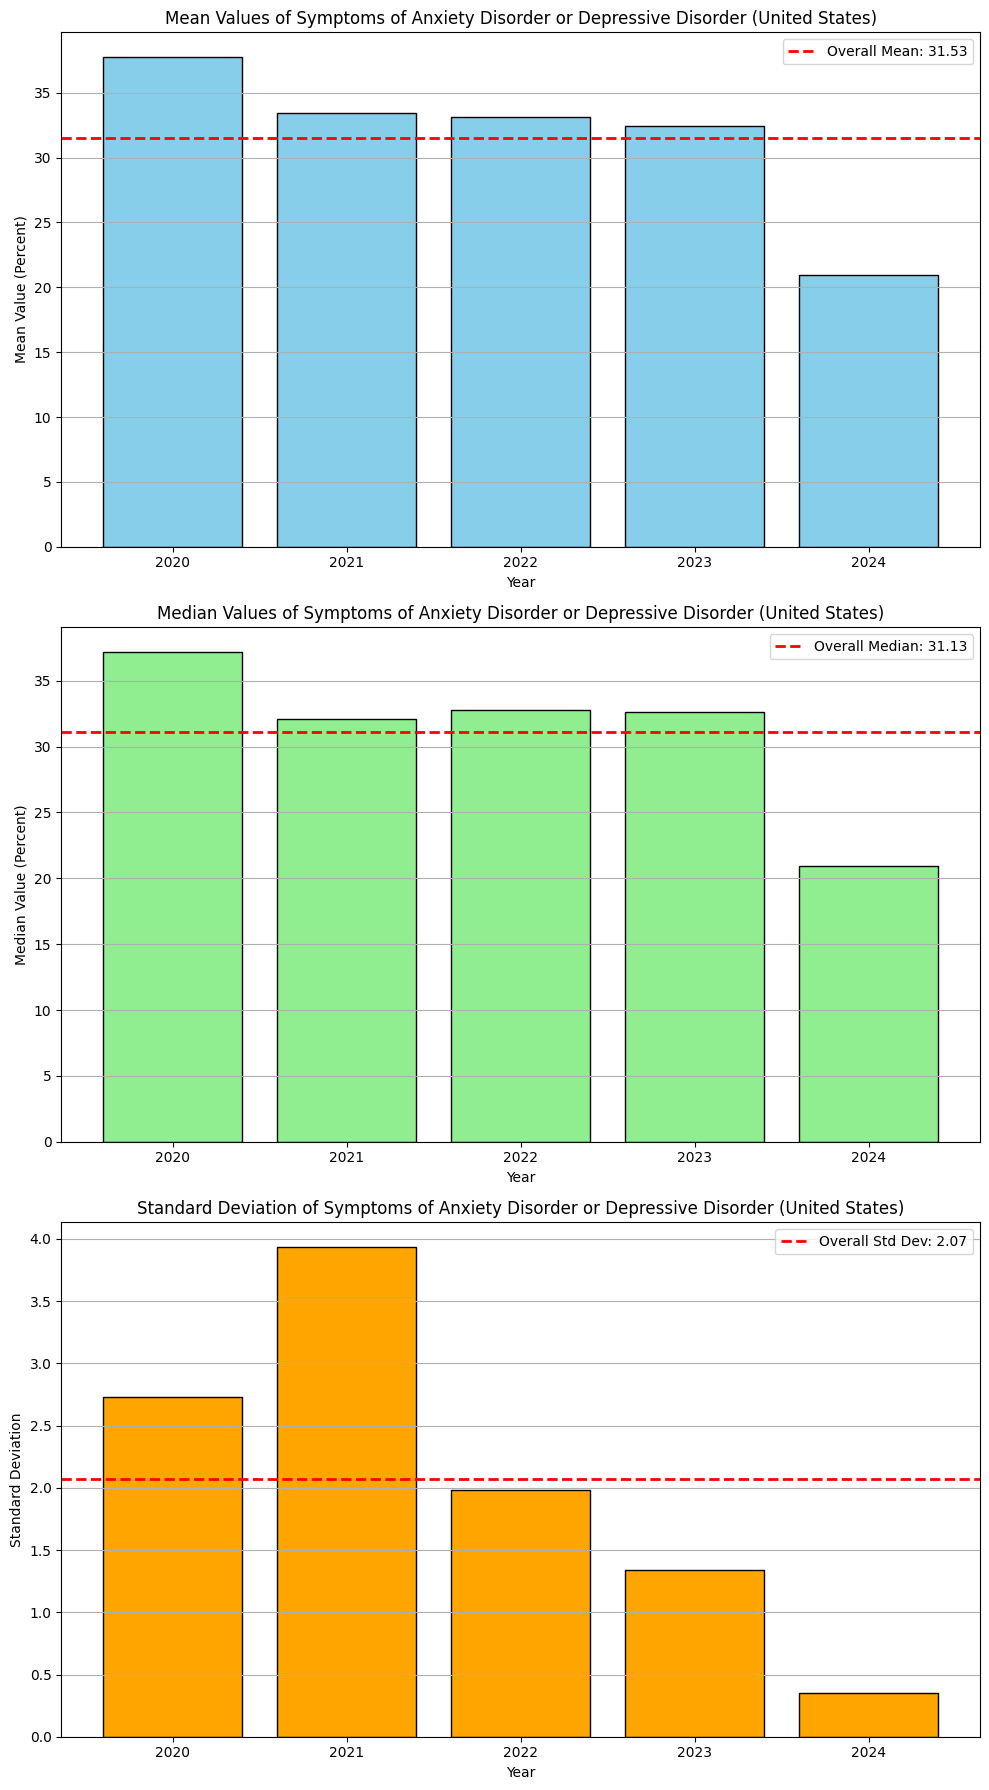

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder" and "United States"
filtered_data = depression_data[
    (depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder') &
    (depression_data['Subgroup'] == 'United States')
]

# Drop rows with missing values in the 'Value' column
cleaned_data = filtered_data.dropna(subset=['Value'])

# Extract the year from the 'Time Period Start Date' for grouping
cleaned_data['Year'] = pd.to_datetime(cleaned_data['Time Period Start Date']).dt.year

# Calculate the mean, median, and standard deviation for each year
stats_by_year = cleaned_data.groupby('Year')['Value'].agg(['mean', 'median', 'std']).reset_index()

# Calculate the overall mean, median, and standard deviation
overall_mean = stats_by_year['mean'].mean()
overall_median = stats_by_year['median'].mean()
overall_std = stats_by_year['std'].mean()

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Mean bar plot
axes[0].bar(stats_by_year['Year'], stats_by_year['mean'], color='skyblue', edgecolor='black')
axes[0].axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
axes[0].set_title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder (United States)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Value (Percent)')
axes[0].legend()
axes[0].grid(axis='y')
axes[0].set_xticks(stats_by_year['Year'])

# Median bar plot
axes[1].bar(stats_by_year['Year'], stats_by_year['median'], color='lightgreen', edgecolor='black')
axes[1].axhline(overall_median, color='red', linestyle='--', linewidth=2, label=f'Overall Median: {overall_median:.2f}')
axes[1].set_title('Median Values of Symptoms of Anxiety Disorder or Depressive Disorder (United States)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Value (Percent)')
axes[1].legend()
axes[1].grid(axis='y')
axes[1].set_xticks(stats_by_year['Year'])

# Standard Deviation bar plot
axes[2].bar(stats_by_year['Year'], stats_by_year['std'], color='orange', edgecolor='black')
axes[2].axhline(overall_std, color='red', linestyle='--', linewidth=2, label=f'Overall Std Dev: {overall_std:.2f}')
axes[2].set_title('Standard Deviation of Symptoms of Anxiety Disorder or Depressive Disorder (United States)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Standard Deviation')
axes[2].legend()
axes[2].grid(axis='y')
axes[2].set_xticks(stats_by_year['Year'])

plt.tight_layout()
plt.show()

# Export the statistics data to a new CSV file for use in Tableau
output_path = 'Cleaned_Corrected_Depression_Symptoms_Stats.csv'
stats_by_year.to_csv(output_path, index=False)


In [15]:
import pandas as pd
import numpy as np

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Calculate mean, median, and standard deviation for the 'Value' column
summary_stats = filtered_data['Value'].agg(['mean', 'median', 'std'])

# Calculate IQR for the 'Value' column
iqr = np.percentile(filtered_data['Value'].dropna(), 75) - np.percentile(filtered_data['Value'].dropna(), 25)
summary_stats['IQR'] = iqr

# Frequency counts for 'Group' and 'Subgroup'
group_counts = filtered_data['Group'].value_counts()
subgroup_counts = filtered_data['Subgroup'].value_counts()

# Display summary statistics and frequency counts
print(summary_stats)
print(group_counts)
print(subgroup_counts)



mean      34.285181
median    33.700000
std        7.938820
IQR        8.400000
Name: Value, dtype: float64
Group
By State                      3315
By Age                         455
By Race/Hispanic ethnicity     325
By Education                   260
By Sex                         130
By Gender identity              96
By Sexual orientation           96
By Disability status            76
National Estimate               65
Name: count, dtype: int64
Subgroup
United States        65
Montana              65
New York             65
New Mexico           65
New Jersey           65
                     ..
Cis-gender female    32
Transgender          32
Gay or lesbian       32
Straight             32
Bisexual             32
Name: count, Length: 78, dtype: int64


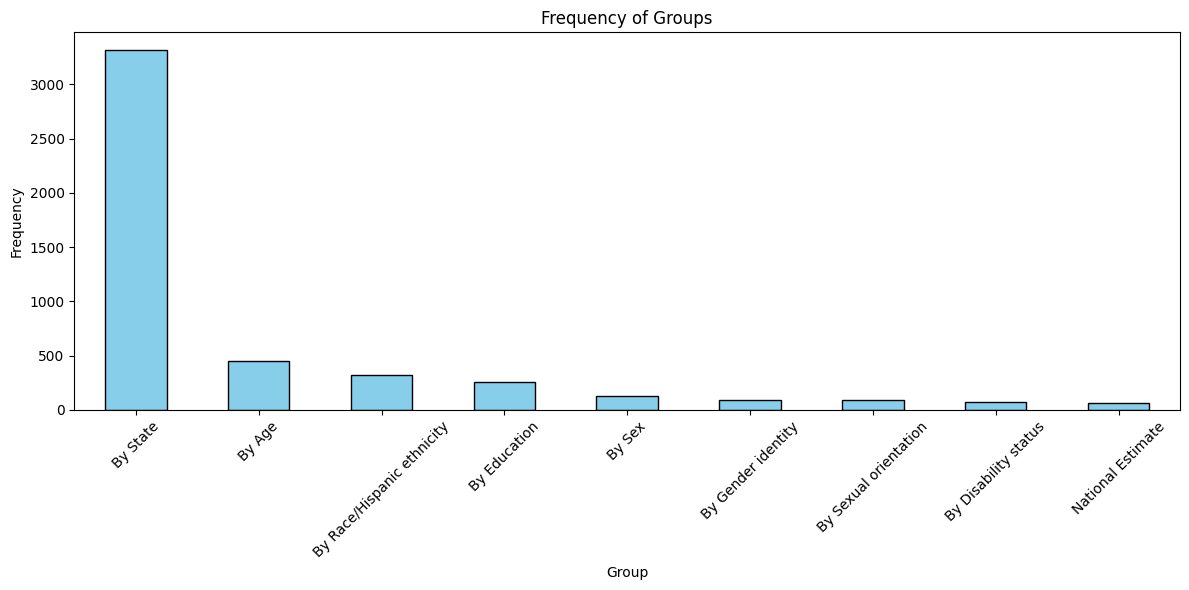

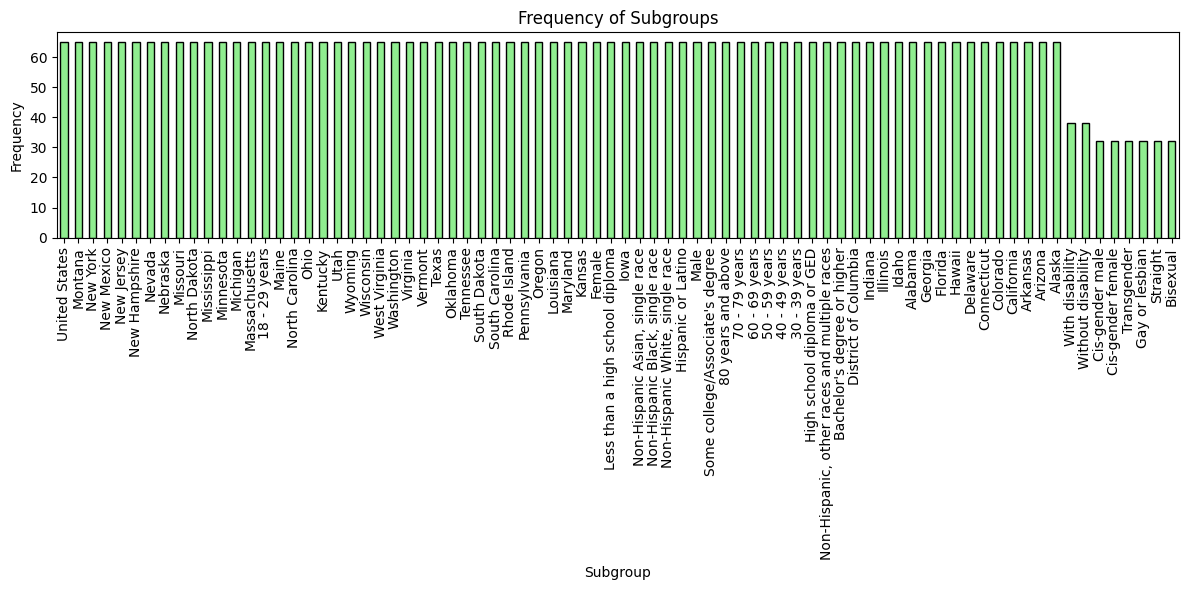

In [17]:
import matplotlib.pyplot as plt

# Bar plot for 'Group'
plt.figure(figsize=(12, 6))
group_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency of Groups')
plt.xlabel('Group')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar plot for 'Subgroup'
plt.figure(figsize=(12, 6))
subgroup_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Frequency of Subgroups')
plt.xlabel('Subgroup')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/2802313841.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


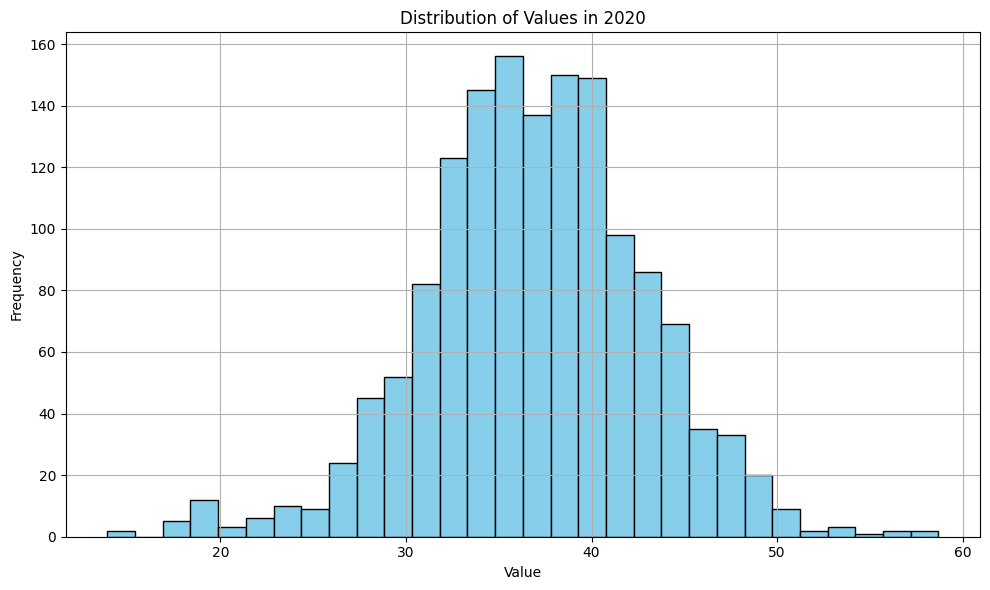

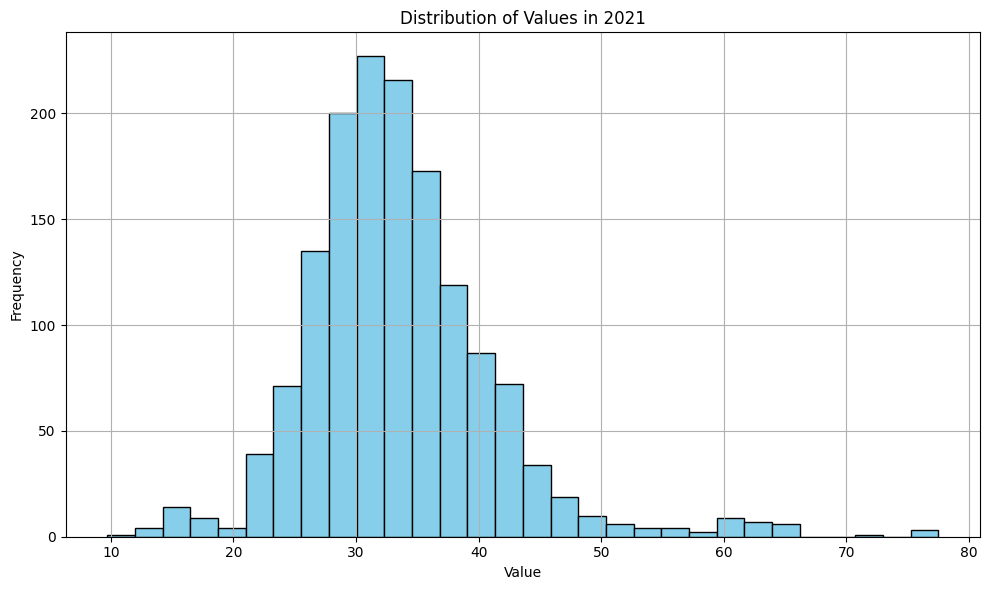

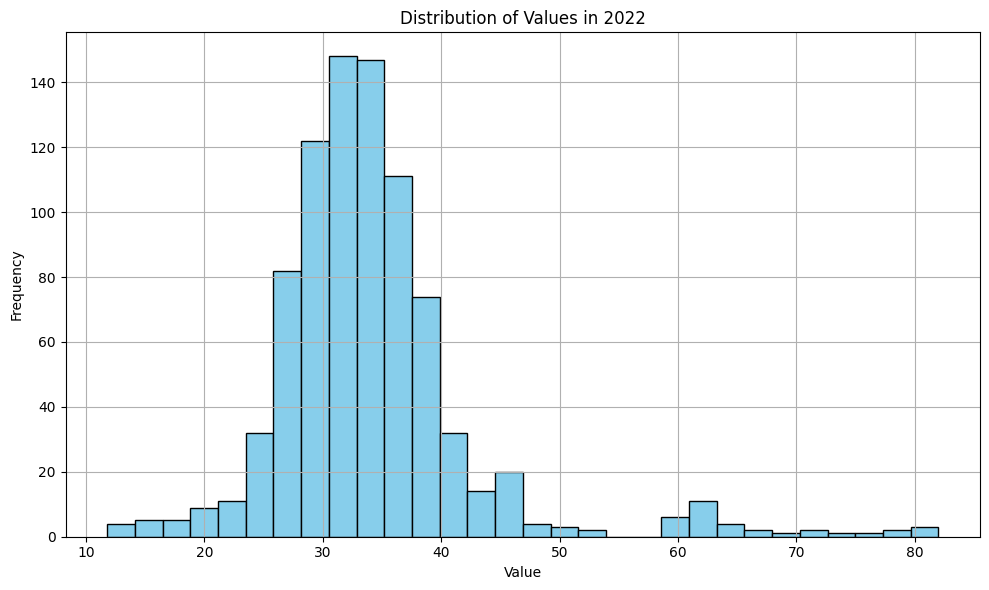

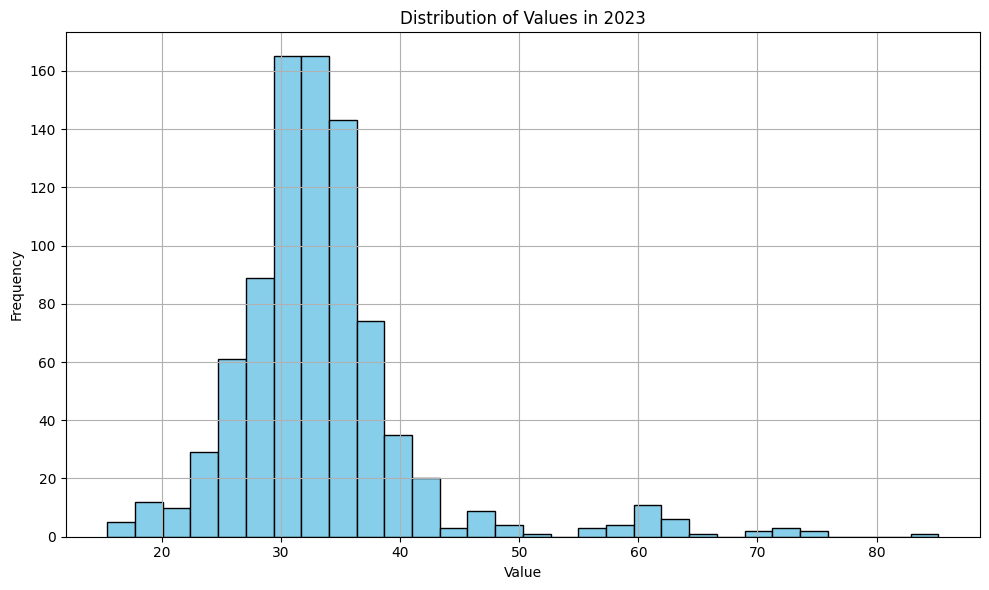

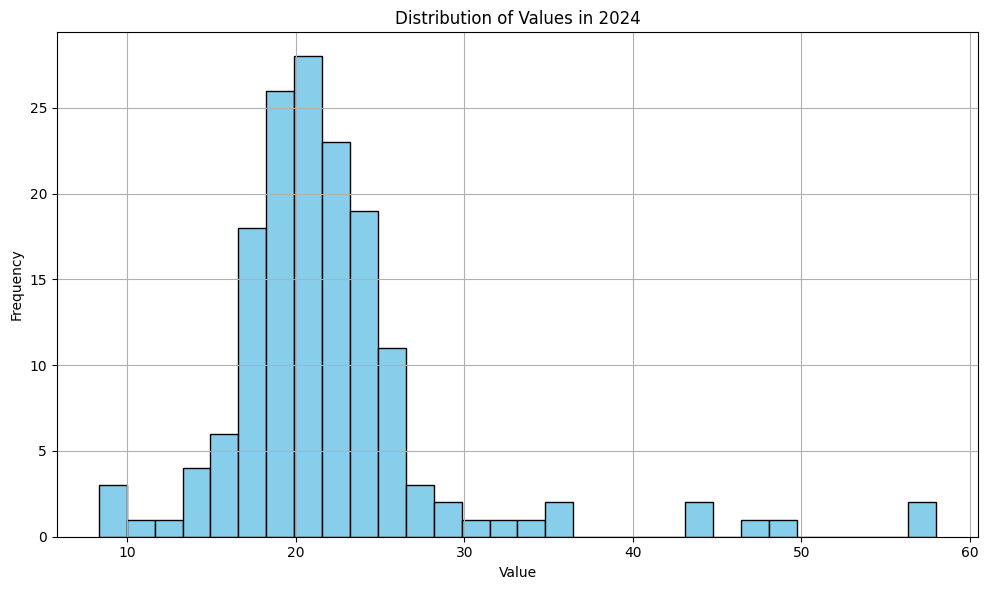

<Figure size 1000x600 with 0 Axes>

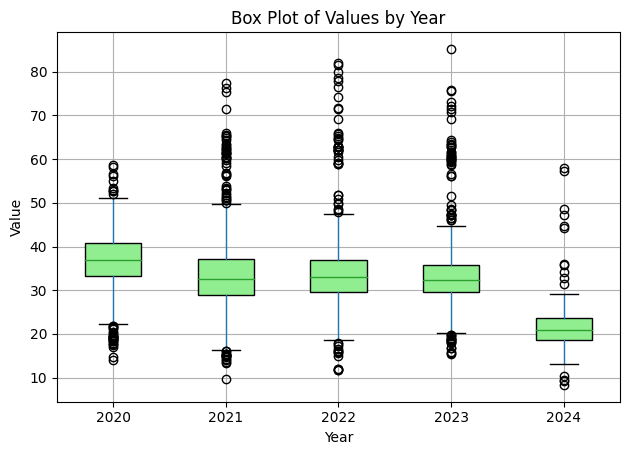

In [18]:
# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Histogram for 'Value' by year
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year
years = filtered_data['Year'].unique()

for year in years:
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_data[filtered_data['Year'] == year]['Value'], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of Values in {year}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Box plot for 'Value' by year
plt.figure(figsize=(10, 6))
filtered_data.boxplot(column='Value', by='Year', patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Box Plot of Values by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.suptitle('')
plt.tight_layout()
plt.show()

/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/1513926854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


<Figure size 1400x800 with 0 Axes>

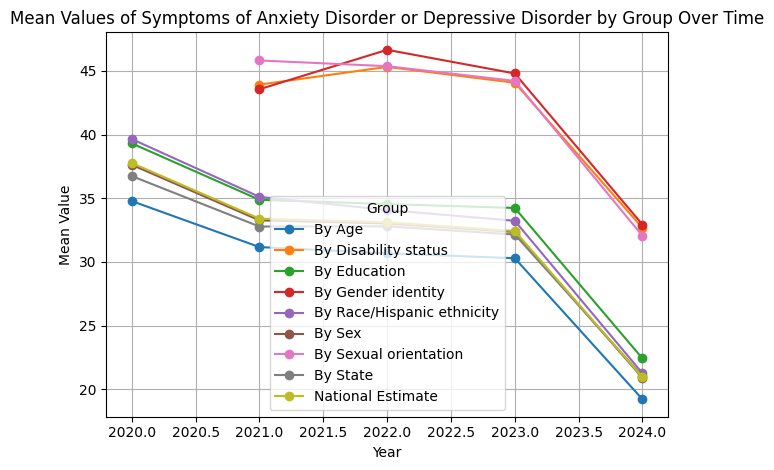

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

# Calculate mean values by group and year
mean_values_by_group = filtered_data.groupby(['Group', 'Year'])['Value'].mean().unstack()

# Plot mean values by group over time
plt.figure(figsize=(14, 8))
mean_values_by_group.T.plot(marker='o')
plt.title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder by Group Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend(title='Group')
plt.grid(True)
plt.tight_layout()
plt.show()



<Figure size 1400x800 with 0 Axes>

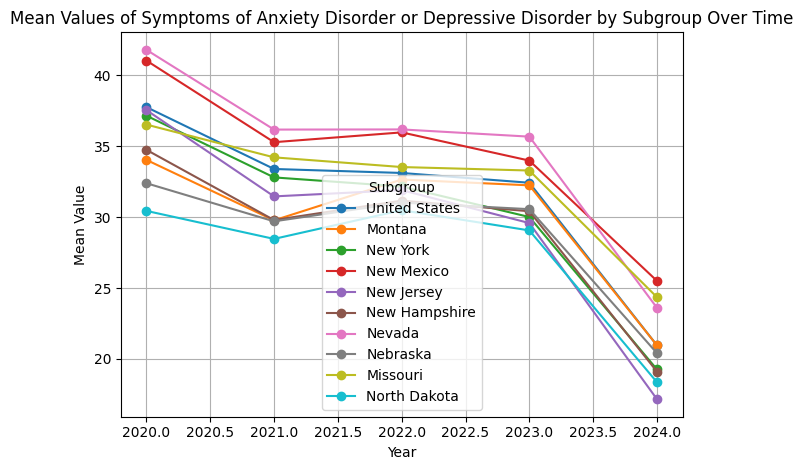

In [20]:
# Calculate mean values by subgroup and year
mean_values_by_subgroup = filtered_data.groupby(['Subgroup', 'Year'])['Value'].mean().unstack()

# Select top subgroups for better visualization (e.g., top 10 most frequent subgroups)
top_subgroups = filtered_data['Subgroup'].value_counts().nlargest(10).index
top_mean_values_by_subgroup = mean_values_by_subgroup.loc[top_subgroups]

# Plot mean values by subgroup over time
plt.figure(figsize=(14, 8))
top_mean_values_by_subgroup.T.plot(marker='o')
plt.title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder by Subgroup Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend(title='Subgroup')
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# Calculate overall summary statistics for filtered data
summary_stats = filtered_data['Value'].agg(['mean', 'median', 'std'])
iqr = np.percentile(filtered_data['Value'].dropna(), 75) - np.percentile(filtered_data['Value'].dropna(), 25)
summary_stats['IQR'] = iqr

# Display summary statistics
print(summary_stats)

mean      34.285181
median    33.700000
std        7.938820
IQR        8.400000
Name: Value, dtype: float64


In [24]:
import pandas as pd

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

filtered_data.head()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/1323401298.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range,Year
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.9,35.0,36.8,35.0 - 36.8,NaN,2020
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,46.8,44.3,49.3,44.3 - 49.3,NaN,2020
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,39.6,37.7,41.5,37.7 - 41.5,NaN,2020
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,38.9,37.2,40.7,37.2 - 40.7,NaN,2020
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.8,34.0,37.7,34.0 - 37.7,NaN,2020


In [26]:
# Define education levels
education_levels = [
    'Less than a high school diploma', 'High school diploma or GED',
    "Some college/Associate's degree", "Bachelor's degree or higher"
]

# Calculate mean values by education level and year
mean_values_by_education = filtered_data[
    filtered_data['Subgroup'].isin(education_levels)
].groupby(['Subgroup', 'Year'])['Value'].mean().unstack()

mean_values_by_education

Year,2020,2021,2022,2023,2024
Subgroup,,,,,
Bachelor's degree or higher,32.004762,27.540,25.963636,24.727273,15.7
High school diploma or GED,38.680952,34.125,34.745455,35.227273,22.0
Less than a high school diploma,45.661905,40.465,39.545455,39.900000,27.6
Some college/Associate's degree,40.880952,37.390,37.936364,37.100000,24.4


In [25]:
# Define identity groups (gender and sexual preference)
identity_groups = [
    'Cis-gender male', 'Cis-gender female', 'Transgender', 
    'Gay or lesbian', 'Straight', 'Bisexual'
]

# Calculate mean values by identity (gender and sexual preference) and year
mean_values_by_identity = filtered_data[
    filtered_data['Subgroup'].isin(identity_groups)
].groupby(['Subgroup', 'Year'])['Value'].mean().unstack()

mean_values_by_identity

Year,2021,2022,2023,2024
Subgroup,,,,
Bisexual,61.5375,61.072727,59.527273,44.45
Cis-gender female,34.4125,35.518182,34.700000,22.15
Cis-gender male,27.4250,29.045455,28.700000,19.05
Gay or lesbian,47.0750,44.736364,43.536364,33.50
Straight,28.8375,30.300000,29.572727,18.20
Transgender,68.8375,75.400000,70.990909,57.60


<Figure size 1400x800 with 0 Axes>

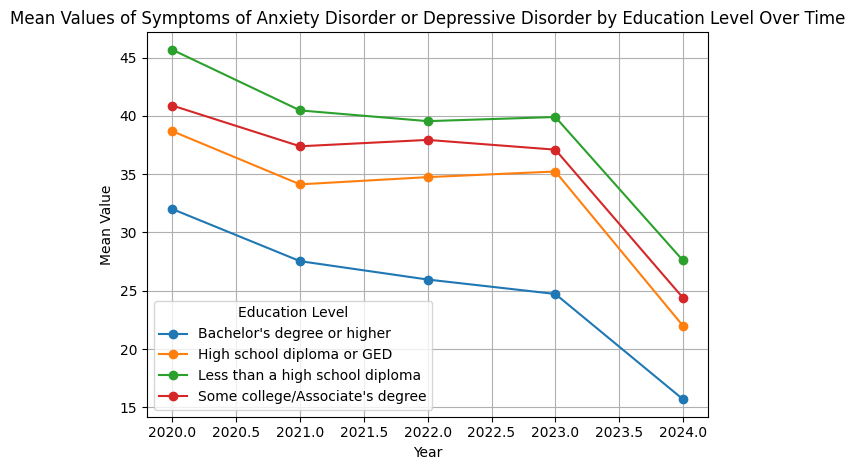

In [27]:
import matplotlib.pyplot as plt

# Plot mean values by education level over time
plt.figure(figsize=(14, 8))
mean_values_by_education.T.plot(marker='o')
plt.title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder by Education Level Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend(title='Education Level')
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1400x800 with 0 Axes>

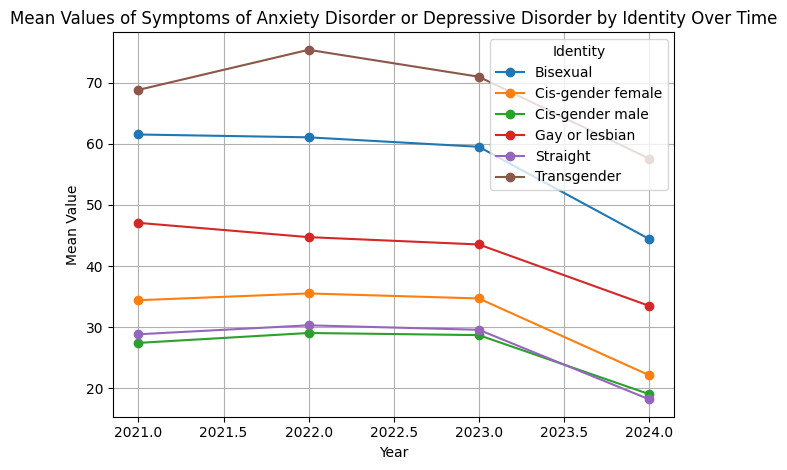

In [28]:
# Plot mean values by identity (gender and sexual preference) over time
plt.figure(figsize=(14, 8))
mean_values_by_identity.T.plot(marker='o')
plt.title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder by Identity Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend(title='Identity')
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

filtered_data.head()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_17671/1323401298.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range,Year
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.9,35.0,36.8,35.0 - 36.8,NaN,2020
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,46.8,44.3,49.3,44.3 - 49.3,NaN,2020
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,39.6,37.7,41.5,37.7 - 41.5,NaN,2020
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,38.9,37.2,40.7,37.2 - 40.7,NaN,2020
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.8,34.0,37.7,34.0 - 37.7,NaN,2020


In [30]:
# Define race groups
race_groups = [
    'Hispanic or Latino', 'Non-Hispanic White, single race',
    'Non-Hispanic Black, single race', 'Non-Hispanic Asian, single race',
    'Non-Hispanic, other races and multiple races'
]

# Calculate mean values by race and year
mean_values_by_race = filtered_data[
    filtered_data['Subgroup'].isin(race_groups)
].groupby(['Subgroup', 'Year'])['Value'].mean().unstack()

mean_values_by_race


Year,2020,2021,2022,2023,2024
Subgroup,,,,,
Hispanic or Latino,43.119048,37.815,36.854545,36.054545,22.80
"Non-Hispanic Asian, single race",31.809524,26.850,23.781818,24.481818,13.20
"Non-Hispanic Black, single race",40.561905,35.625,33.718182,32.409091,19.35
"Non-Hispanic White, single race",35.880952,31.915,32.145455,31.545455,20.70
"Non-Hispanic, other races and multiple races",46.852381,43.345,43.909091,41.645455,30.25


<Figure size 1400x800 with 0 Axes>

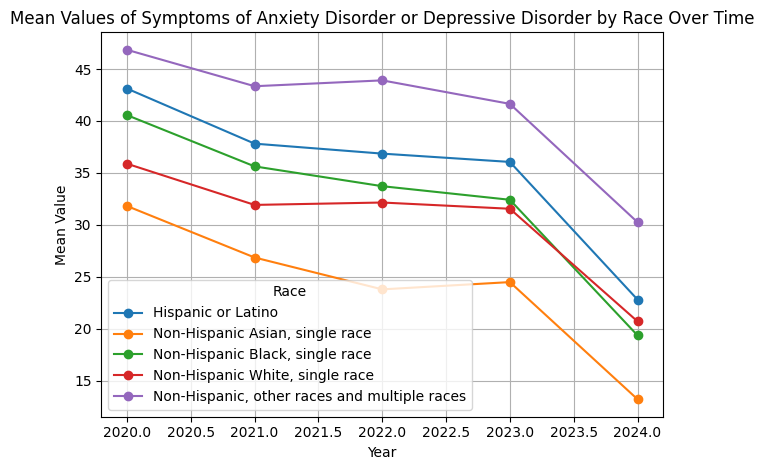

In [31]:
import matplotlib.pyplot as plt

# Plot mean values by race over time
plt.figure(figsize=(14, 8))
mean_values_by_race.T.plot(marker='o')
plt.title('Mean Values of Symptoms of Anxiety Disorder or Depressive Disorder by Race Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend(title='Race')
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

filtered_data.head()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/1323401298.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range,Year
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.9,35.0,36.8,35.0 - 36.8,NaN,2020
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,46.8,44.3,49.3,44.3 - 49.3,NaN,2020
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,39.6,37.7,41.5,37.7 - 41.5,NaN,2020
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,38.9,37.2,40.7,37.2 - 40.7,NaN,2020
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.8,34.0,37.7,34.0 - 37.7,NaN,2020


In [2]:
# Filter for state-level data
state_data = filtered_data[filtered_data['Group'] == 'By State']

# Aggregate data by state and calculate mean value for clustering
state_aggregated = state_data.groupby('State')['Value'].agg(['mean', 'median', 'std', 'min', 'max']).reset_index()

state_aggregated.head()


,State,mean,median,std,min,max
0,Alabama,35.640000,36.0,4.825317,21.4,44.8
1,Alaska,34.480000,34.8,4.488534,24.3,44.6
2,Arizona,34.907692,34.4,5.110446,19.2,44.9
3,Arkansas,37.103077,37.5,4.634482,24.0,47.2
4,California,35.823077,34.4,5.263161,21.3,46.1


In [3]:
from sklearn.preprocessing import StandardScaler

# Normalize the data
scaler = StandardScaler()
state_aggregated_scaled = scaler.fit_transform(state_aggregated.drop('State', axis=1))

state_aggregated_scaled


array([[ 8.19321719e-01,  1.00792328e+00, -1.51246944e-01,
         5.33239244e-01,  1.21392012e-02],
       [ 3.54587415e-01,  5.44475462e-01, -7.93586952e-01,
         1.64090896e+00, -5.66496056e-02],
       [ 5.25935076e-01,  3.89992855e-01,  3.92573188e-01,
        -3.07061924e-01,  4.65336046e-02],
       [ 1.40547865e+00,  1.58723306e+00, -5.15222391e-01,
         1.52632244e+00,  8.37604882e-01],
       [ 8.92668379e-01,  3.89992855e-01,  6.83843637e-01,
         4.95043736e-01,  4.59266445e-01],
       [ 9.26350558e-02, -1.12075617e-01,  4.98824207e-01,
         3.04066198e-01,  3.56083235e-01],
       [-4.73798399e-01, -4.21040830e-01,  6.75105186e-01,
        -3.45257432e-01, -1.01969290e+00],
       [-1.10988036e+00, -8.84488651e-01,  5.56901255e-01,
        -1.41473165e+00, -6.41354463e-01],
       [-1.92122568e-01, -7.34549650e-02,  3.24811053e+00,
        -1.37653614e+00,  1.83504258e+00],
       [ 5.00664378e-01,  5.05854811e-01,  2.23317043e-01,
        -2.68866416e-01

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-p

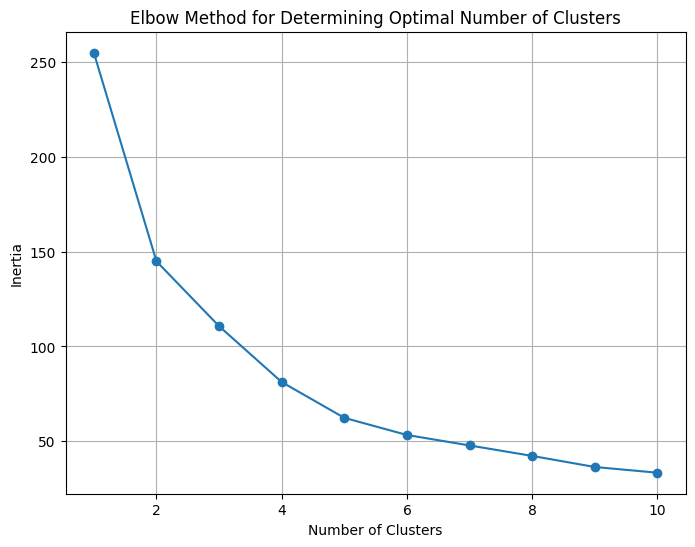

In [4]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the elbow method
import matplotlib.pyplot as plt

inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=0)
    kmeans.fit(state_aggregated_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Determining Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [5]:
# Apply K-Means with the chosen number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0)
state_aggregated['Cluster'] = kmeans.fit_predict(state_aggregated_scaled)

state_aggregated.head()


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,State,mean,median,std,min,max,Cluster
0,Alabama,35.640000,36.0,4.825317,21.4,44.8,2
1,Alaska,34.480000,34.8,4.488534,24.3,44.6,2
2,Arizona,34.907692,34.4,5.110446,19.2,44.9,2
3,Arkansas,37.103077,37.5,4.634482,24.0,47.2,2
4,California,35.823077,34.4,5.263161,21.3,46.1,2


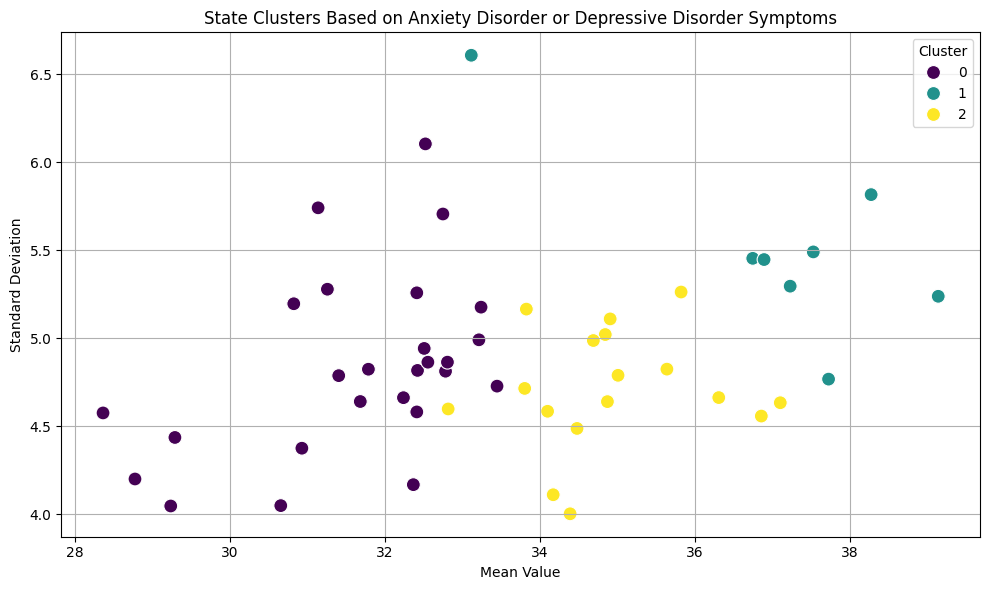

In [6]:
import seaborn as sns

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=state_aggregated, x='mean', y='std', hue='Cluster', palette='viridis', s=100)
plt.title('State Clusters Based on Anxiety Disorder or Depressive Disorder Symptoms')
plt.xlabel('Mean Value')
plt.ylabel('Standard Deviation')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# Save the clustered data to a new CSV file
output_path = 'Clustered_State_Data.csv'
state_aggregated.to_csv(output_path, index=False)


In [8]:
import pandas as pd

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

filtered_data.head()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/1323401298.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range,Year
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.9,35.0,36.8,35.0 - 36.8,NaN,2020
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,46.8,44.3,49.3,44.3 - 49.3,NaN,2020
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,39.6,37.7,41.5,37.7 - 41.5,NaN,2020
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,38.9,37.2,40.7,37.2 - 40.7,NaN,2020
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.8,34.0,37.7,34.0 - 37.7,NaN,2020


In [9]:
# Pivot the data to get states as rows and years as columns
state_time_series = filtered_data.pivot_table(index='State', columns='Year', values='Value')

# Fill missing values with interpolation or forward/backward fill
state_time_series = state_time_series.interpolate(method='linear', axis=1).ffill(axis=1).bfill(axis=1)

state_time_series.head()


Year,2020,2021,2022,2023,2024
State,,,,,
Alabama,37.023810,34.950,36.127273,36.181818,22.35
Alaska,36.790476,34.535,34.027273,32.127273,25.10
Arizona,39.009524,34.245,33.554545,32.427273,19.55
Arkansas,39.100000,36.930,37.200000,35.781818,24.60
California,40.328571,35.360,34.063636,32.418182,21.55


In [10]:
from sklearn.preprocessing import StandardScaler

# Normalize the time series data
scaler = StandardScaler()
state_time_series_scaled = scaler.fit_transform(state_time_series)

state_time_series_scaled


array([[ 0.0997143 ,  0.81152874,  1.18584333,  1.42237428,  0.49681551],
       [ 0.01334163,  0.65301767,  0.4207539 , -0.03509466,  1.57993503],
       [ 0.83476335,  0.54225089,  0.24852597,  0.07274497, -0.6059971 ],
       [ 0.86825479,  1.56779845,  1.57666824,  1.27858811,  1.38300421],
       [ 1.32303334,  0.96813005,  0.4340022 ,  0.0694771 ,  0.18172619],
       [ 0.35883231,  0.05143949, -0.37414422,  0.03026269, -0.11367004],
       [-0.01838711, -0.56923641, -0.67554309, -0.80304355, -0.78323484],
       [-0.92970691, -0.72965726, -1.49031366, -1.25727714, -1.68911662],
       [ 0.57211992,  0.32262711, -0.83121064, -1.61674258, -1.74819586],
       [ 0.9652037 ,  0.2691535 , -0.00981592,  0.37992452, -0.36968011],
       [ 0.50513703,  0.63773949, -0.07605743,  0.56619297,  0.59528092],
       [-0.61418226, -0.72583771, -1.06305592, -1.57752817, -1.84666127],
       [-0.60713143, -0.58451458, -0.68216724,  0.34071011,  0.31957777],
       [ 0.51747599, -0.447011  , -0.4

In [11]:
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import dtw

# Apply K-Means with DTW as the distance metric
n_clusters = 3  # Choose the number of clusters
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0)
state_time_series['Cluster'] = km.fit_predict(state_time_series_scaled)

state_time_series.head()


Year,2020,2021,2022,2023,2024,Cluster
State,,,,,,
Alabama,37.023810,34.950,36.127273,36.181818,22.35,0
Alaska,36.790476,34.535,34.027273,32.127273,25.10,0
Arizona,39.009524,34.245,33.554545,32.427273,19.55,1
Arkansas,39.100000,36.930,37.200000,35.781818,24.60,0
California,40.328571,35.360,34.063636,32.418182,21.55,0


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/762530174.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


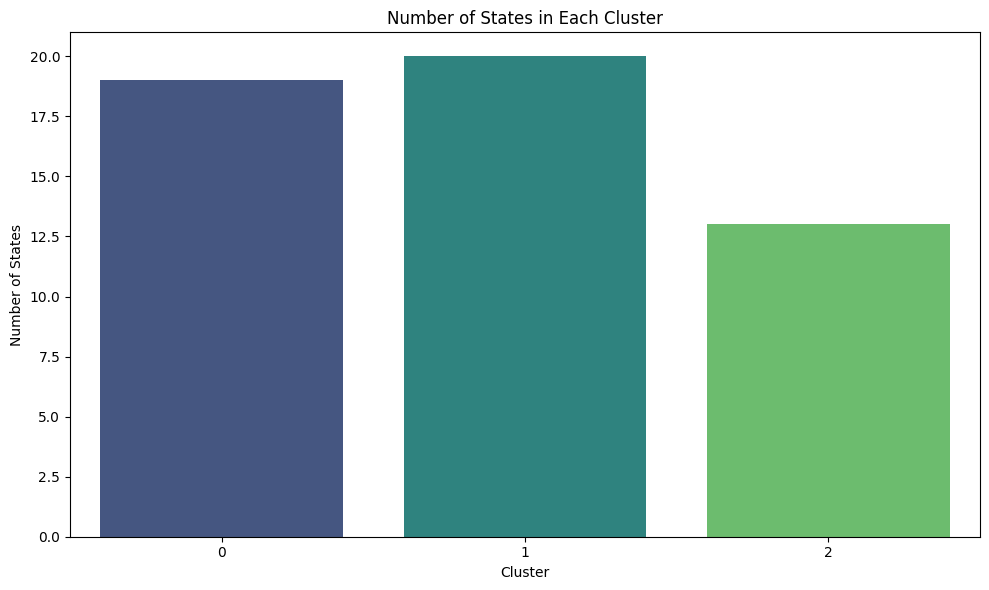

ModuleNotFoundError: No module named 'ace_tools'

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame to display states in each cluster
clustered_states = state_time_series[['Cluster']].reset_index()
clustered_states = clustered_states.sort_values('Cluster')

# Plot the number of states in each cluster
cluster_counts = clustered_states['Cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Number of States in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of States')
plt.tight_layout()
plt.show()

# Display states in each cluster as a table
clustered_states_table = clustered_states.groupby('Cluster')['State'].apply(list).reset_index()

import ace_tools as tools; tools.display_dataframe_to_user(name="Clustered States", dataframe=clustered_states_table)
clustered_states_table


In [ ]:
# Save the clustered data to a new CSV file
output_path = 'Clustered_State_Time_Series_Data.csv'
state_time_series.to_csv(output_path, index=True)


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/2741353553.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


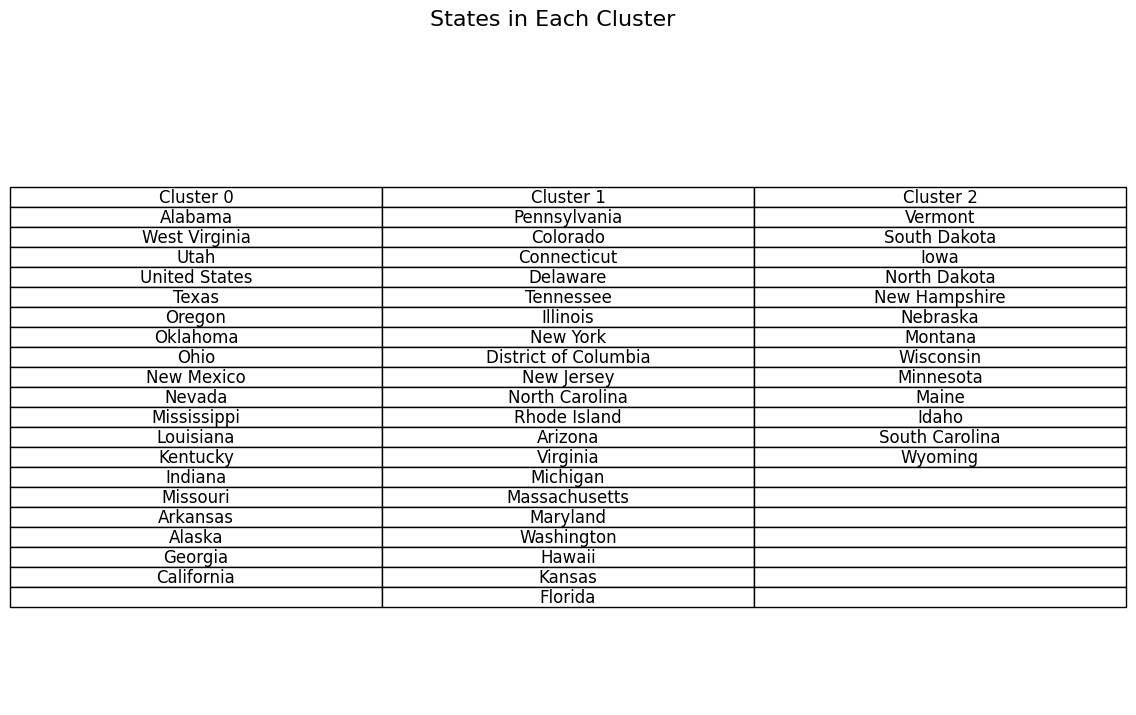

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

# Pivot the data to get states as rows and years as columns
state_time_series = filtered_data.pivot_table(index='State', columns='Year', values='Value')

# Fill missing values with interpolation or forward/backward fill
state_time_series = state_time_series.interpolate(method='linear', axis=1).ffill(axis=1).bfill(axis=1)

# Normalize the time series data
scaler = StandardScaler()
state_time_series_scaled = scaler.fit_transform(state_time_series)

# Apply K-Means with DTW as the distance metric
n_clusters = 3  # Choose the number of clusters
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0)
state_time_series['Cluster'] = km.fit_predict(state_time_series_scaled)

# Create a DataFrame to display states in each cluster
clustered_states = state_time_series[['Cluster']].reset_index()
clustered_states = clustered_states.sort_values('Cluster')

# Display states in each cluster as a list
clusters = []
for cluster in range(n_clusters):
    states_in_cluster = clustered_states[clustered_states['Cluster'] == cluster]['State'].tolist()
    clusters.append(states_in_cluster)

# Plot the clusters as text lists in a table format
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('States in Each Cluster', fontsize=16)

# Define column and row configurations
columns = [f'Cluster {i}' for i in range(n_clusters)]
rows = max(len(cluster) for cluster in clusters)

# Create table with state names
table_data = []
for i in range(rows):
    row = []
    for cluster in clusters:
        if i < len(cluster):
            row.append(cluster[i])
        else:
            row.append("")
    table_data.append(row)

# Plot the table
table = plt.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Hide axes
ax.axis('off')
plt.show()



/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/3726867903.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


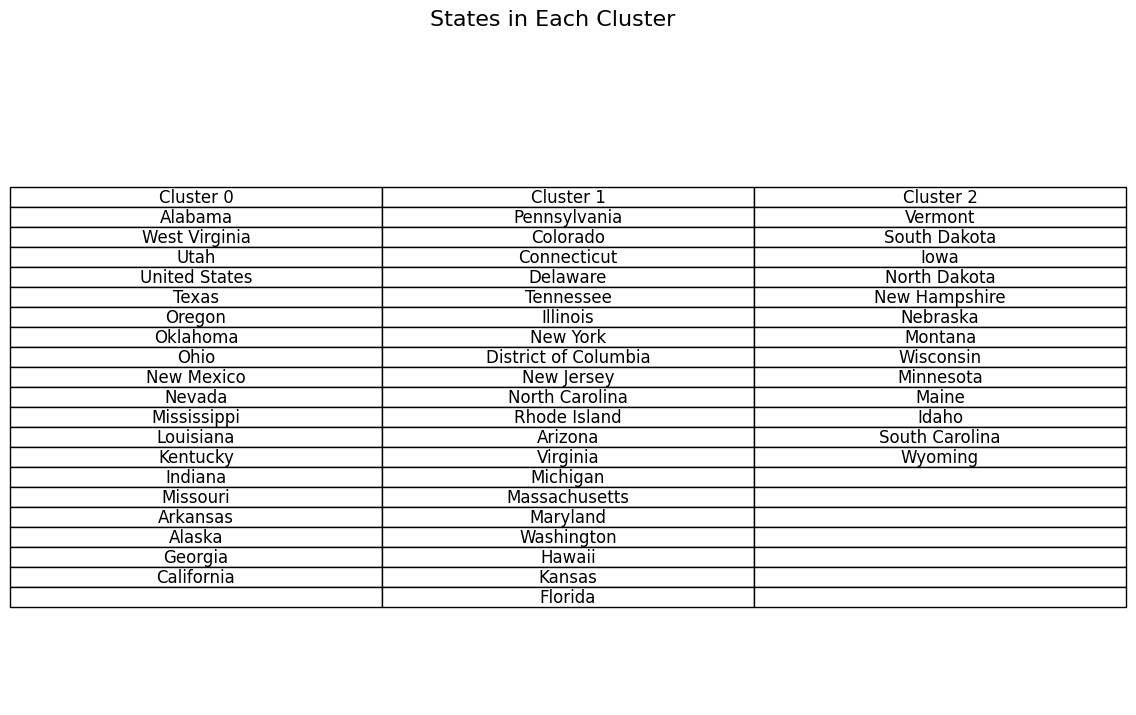

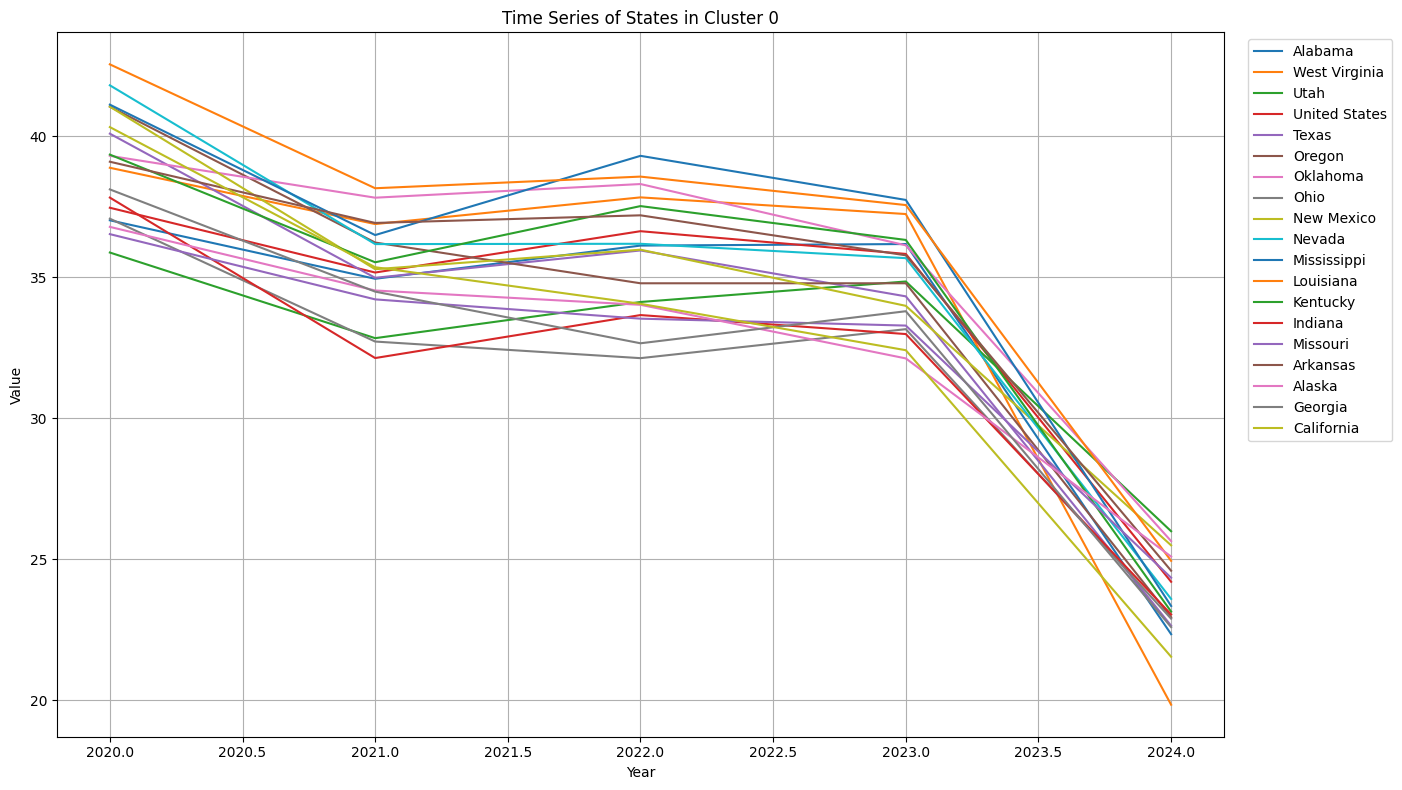

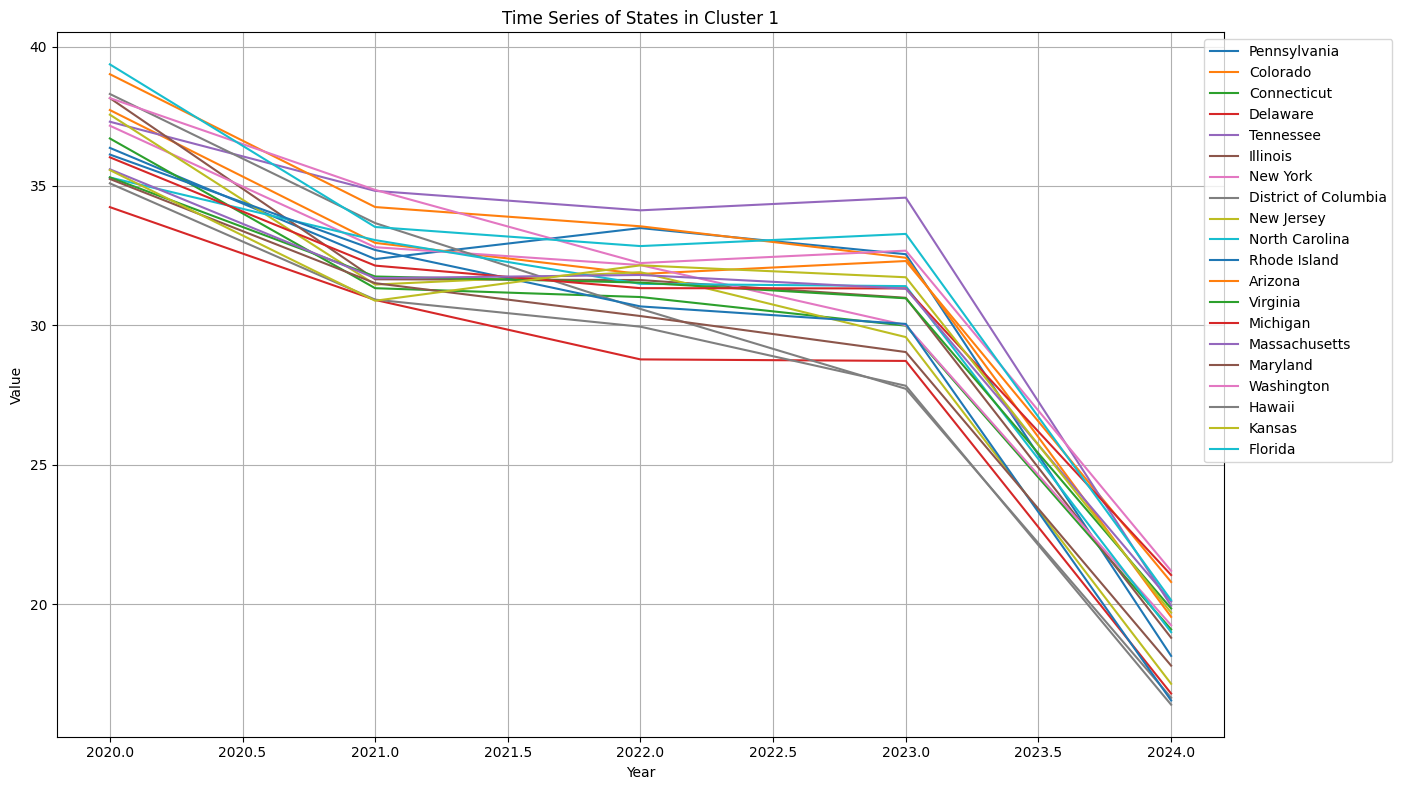

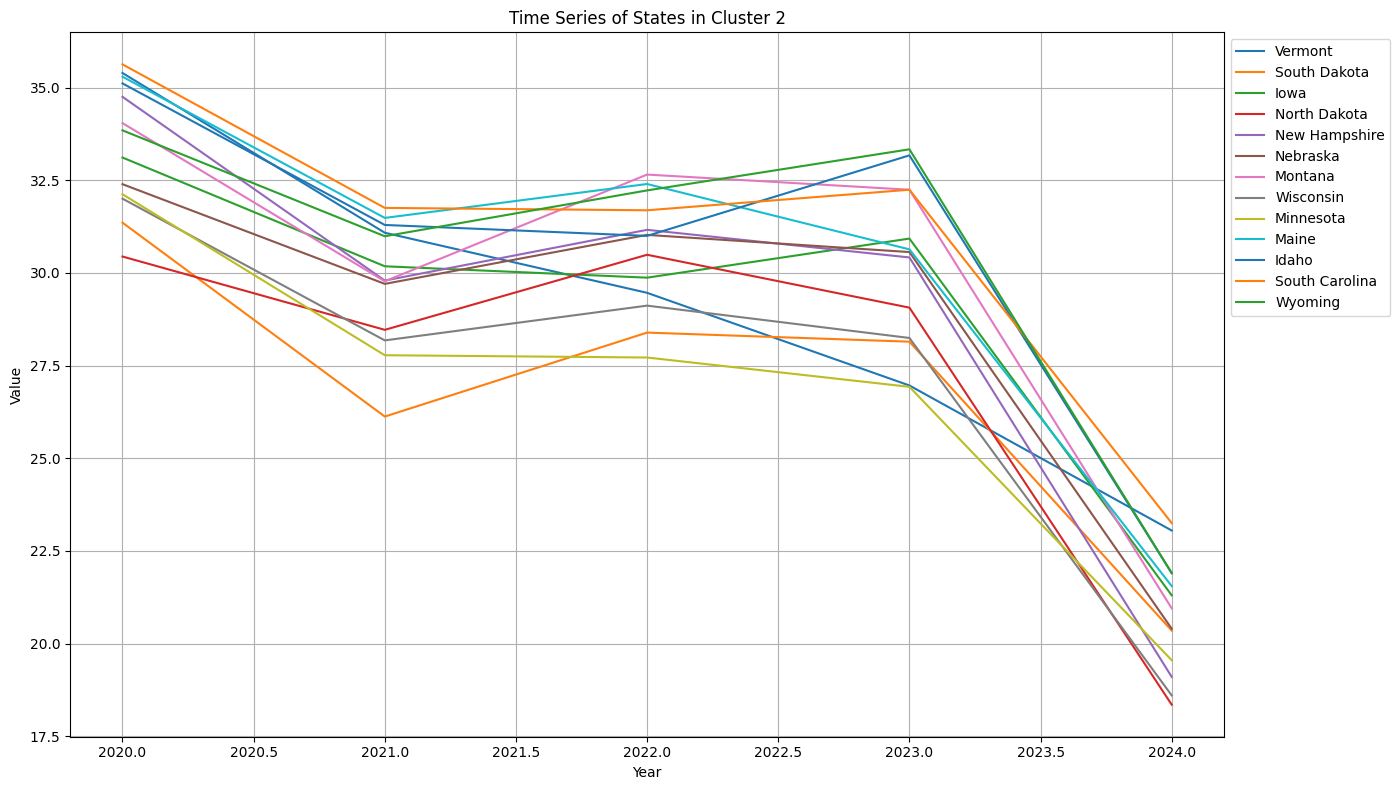

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

# Pivot the data to get states as rows and years as columns
state_time_series = filtered_data.pivot_table(index='State', columns='Year', values='Value')

# Fill missing values with interpolation or forward/backward fill
state_time_series = state_time_series.interpolate(method='linear', axis=1).ffill(axis=1).bfill(axis=1)

# Normalize the time series data
scaler = StandardScaler()
state_time_series_scaled = scaler.fit_transform(state_time_series)

# Apply K-Means with DTW as the distance metric
n_clusters = 3  # Choose the number of clusters
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0)
state_time_series['Cluster'] = km.fit_predict(state_time_series_scaled)

# Create a DataFrame to display states in each cluster
clustered_states = state_time_series[['Cluster']].reset_index()
clustered_states = clustered_states.sort_values('Cluster')

# Display states in each cluster as a list
clusters = []
for cluster in range(n_clusters):
    states_in_cluster = clustered_states[clustered_states['Cluster'] == cluster]['State'].tolist()
    clusters.append(states_in_cluster)

# Plot the clusters as text lists in a table format
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('States in Each Cluster', fontsize=16)

# Define column and row configurations
columns = [f'Cluster {i}' for i in range(n_clusters)]
rows = max(len(cluster) for cluster in clusters)

# Create table with state names
table_data = []
for i in range(rows):
    row = []
    for cluster in clusters:
        if i < len(cluster):
            row.append(cluster[i])
        else:
            row.append("")
    table_data.append(row)

# Plot the table
table = plt.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Hide axes
ax.axis('off')
plt.show()

# Plot the time series for each cluster
for cluster_num in range(n_clusters):
    plt.figure(figsize=(14, 8))
    cluster_states = clusters[cluster_num]
    for state in cluster_states:
        plt.plot(state_time_series.columns[:-1], state_time_series.loc[state].values[:-1], label=state)
    plt.title(f'Time Series of States in Cluster {cluster_num}')
    plt.xlabel('Year')
    plt.ylabel('Value')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/776326632.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frame

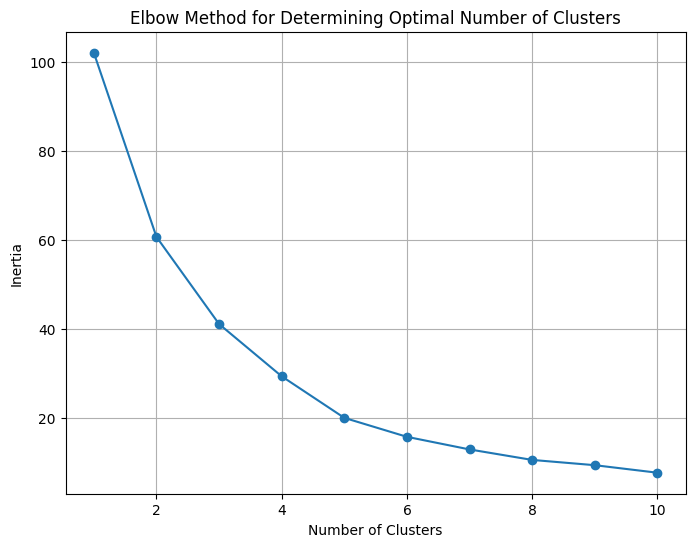

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


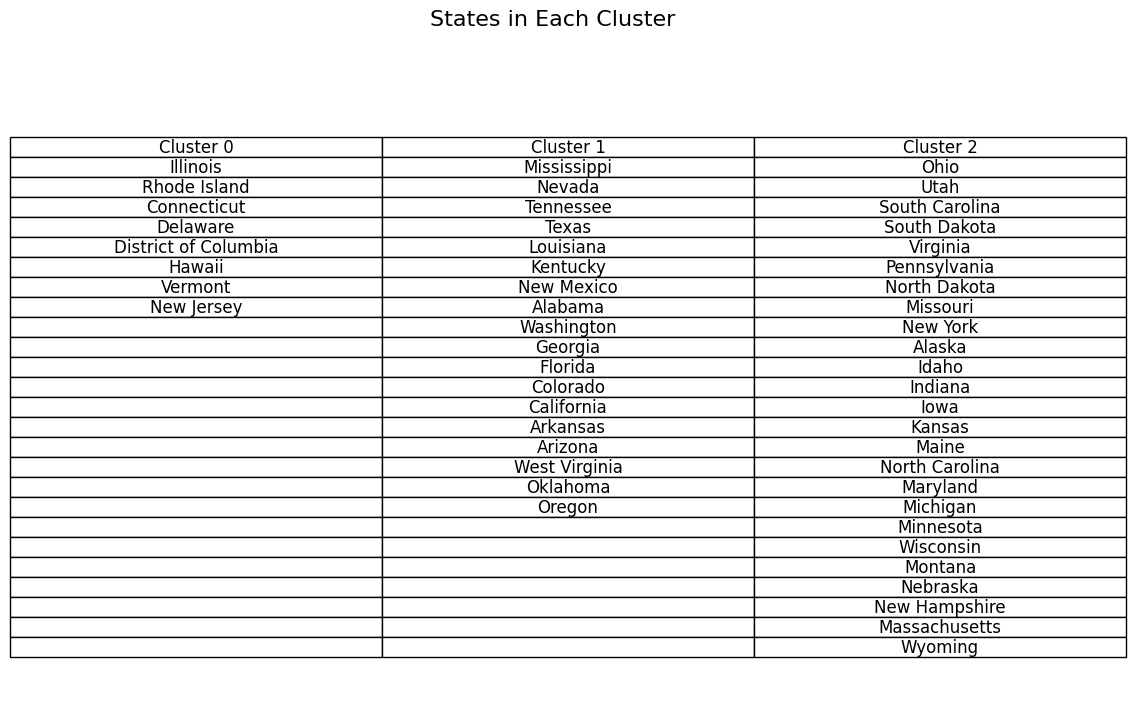

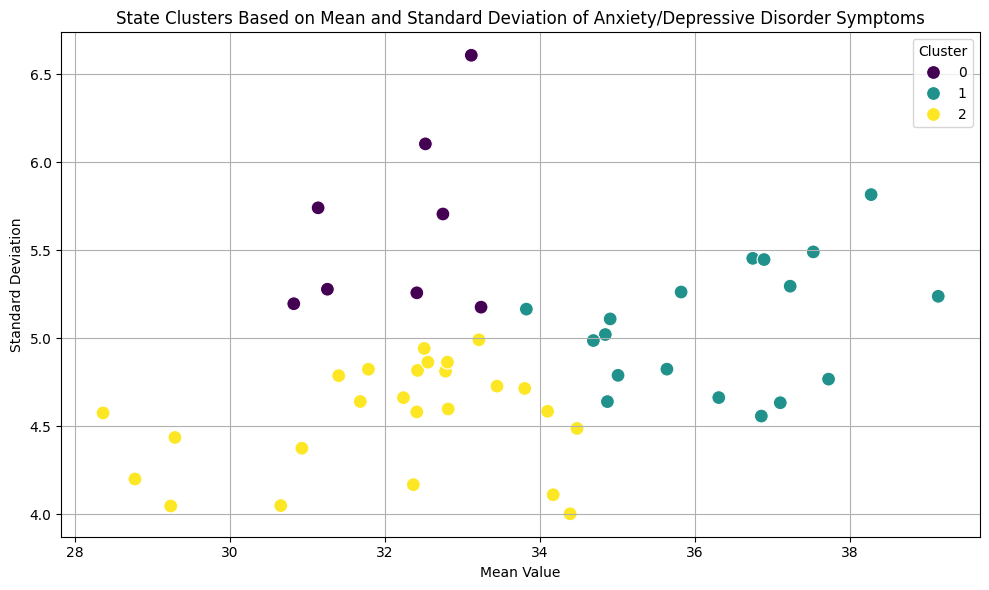

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year

# Filter for state-level data
state_data = filtered_data[filtered_data['Group'] == 'By State']

# Aggregate data by state and calculate mean and standard deviation for clustering
state_aggregated = state_data.groupby('State')['Value'].agg(['mean', 'std']).reset_index()

# Normalize the data
scaler = StandardScaler()
state_aggregated_scaled = scaler.fit_transform(state_aggregated[['mean', 'std']])

# Determine the optimal number of clusters using the elbow method
inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=0)
    kmeans.fit(state_aggregated_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Determining Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Based on the elbow curve, choose the optimal number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0)
state_aggregated['Cluster'] = kmeans.fit_predict(state_aggregated_scaled)

# Create a DataFrame to display states in each cluster
clustered_states = state_aggregated.sort_values('Cluster')

# Display states in each cluster as a list
clusters = []
for cluster in range(optimal_clusters):
    states_in_cluster = clustered_states[clustered_states['Cluster'] == cluster]['State'].tolist()
    clusters.append(states_in_cluster)

# Plot the clusters as text lists in a table format
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('States in Each Cluster', fontsize=16)

# Define column and row configurations
columns = [f'Cluster {i}' for i in range(optimal_clusters)]
rows = max(len(cluster) for cluster in clusters)

# Create table with state names
table_data = []
for i in range(rows):
    row = []
    for cluster in clusters:
        if i < len(cluster):
            row.append(cluster[i])
        else:
            row.append("")
    table_data.append(row)

# Plot the table
table = plt.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Hide axes
ax.axis('off')
plt.show()

# Plot the clusters with mean and standard deviation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=state_aggregated, x='mean', y='std', hue='Cluster', palette='viridis', s=100)
plt.title('State Clusters Based on Mean and Standard Deviation of Anxiety/Depressive Disorder Symptoms')
plt.xlabel('Mean Value')
plt.ylabel('Standard Deviation')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/1953886414.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.fr

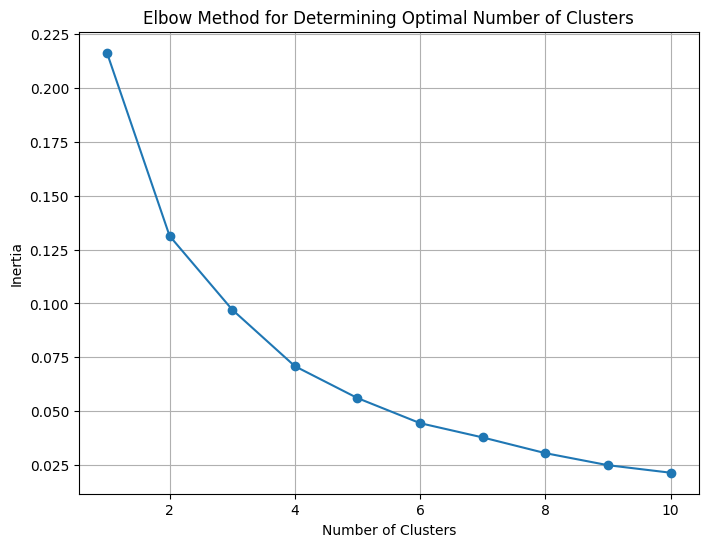

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from sklearn.cluster import KMeans

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year and month from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year
filtered_data['Month'] = filtered_data['Time Period Start Date'].dt.month

filtered_data.head()

# Filter for June (6) and July (7)
mid_year_data = filtered_data[filtered_data['Month'].isin([6, 7])]

# Ensure we have data for each state and mid-year month (June or July)
mid_year_data = mid_year_data.groupby(['State', 'Year']).first().reset_index()

# Combine mid-year data with the original full-year data
combined_data = pd.concat([filtered_data, mid_year_data], ignore_index=True)

# Update the 'Year' column to include mid-year points
combined_data['Year'] = combined_data.apply(
    lambda row: row['Year'] + 0.5 if row['Month'] in [6, 7] else row['Year'], axis=1
)

combined_data.head()


# Pivot the data to get states as rows and years (including mid-years) as columns
state_time_series = combined_data.pivot_table(index='State', columns='Year', values='Value')

# Sort the columns to ensure the mid-year points are in the correct order
state_time_series = state_time_series.reindex(sorted(state_time_series.columns), axis=1)

state_time_series.head()


# Calculate the Pearson correlation coefficient and convert it to a distance metric
correlation_matrix = state_time_series.T.corr()
distance_matrix = 1 - correlation_matrix

# Convert the distance matrix to a set of features using MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
features = mds.fit_transform(distance_matrix)

# Determine the optimal number of clusters using the elbow method
inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=0)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Determining Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Based on the elbow curve, choose the optimal number of clusters
optimal_clusters = 2
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0)
state_time_series['Cluster'] = kmeans.fit_predict(features)

# Create a DataFrame to display states in each cluster
clustered_states = state_time_series[['Cluster']].reset_index()
clustered_states = clustered_states.sort_values('Cluster')

# Display states in each cluster as a list
clusters = []
for cluster in range(optimal_clusters):
    states_in_cluster = clustered_states[clustered_states['Cluster'] == cluster]['State'].tolist()
    clusters.append(states_in_cluster)

# Plot the clusters as text lists in a table format
fig, ax


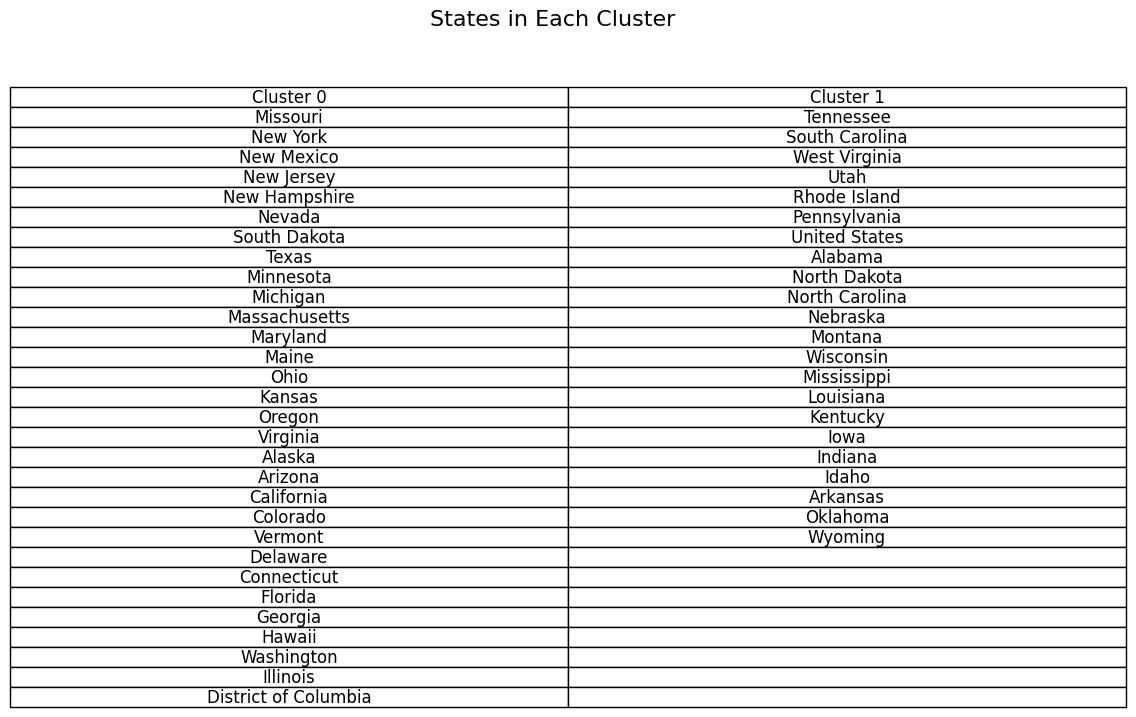

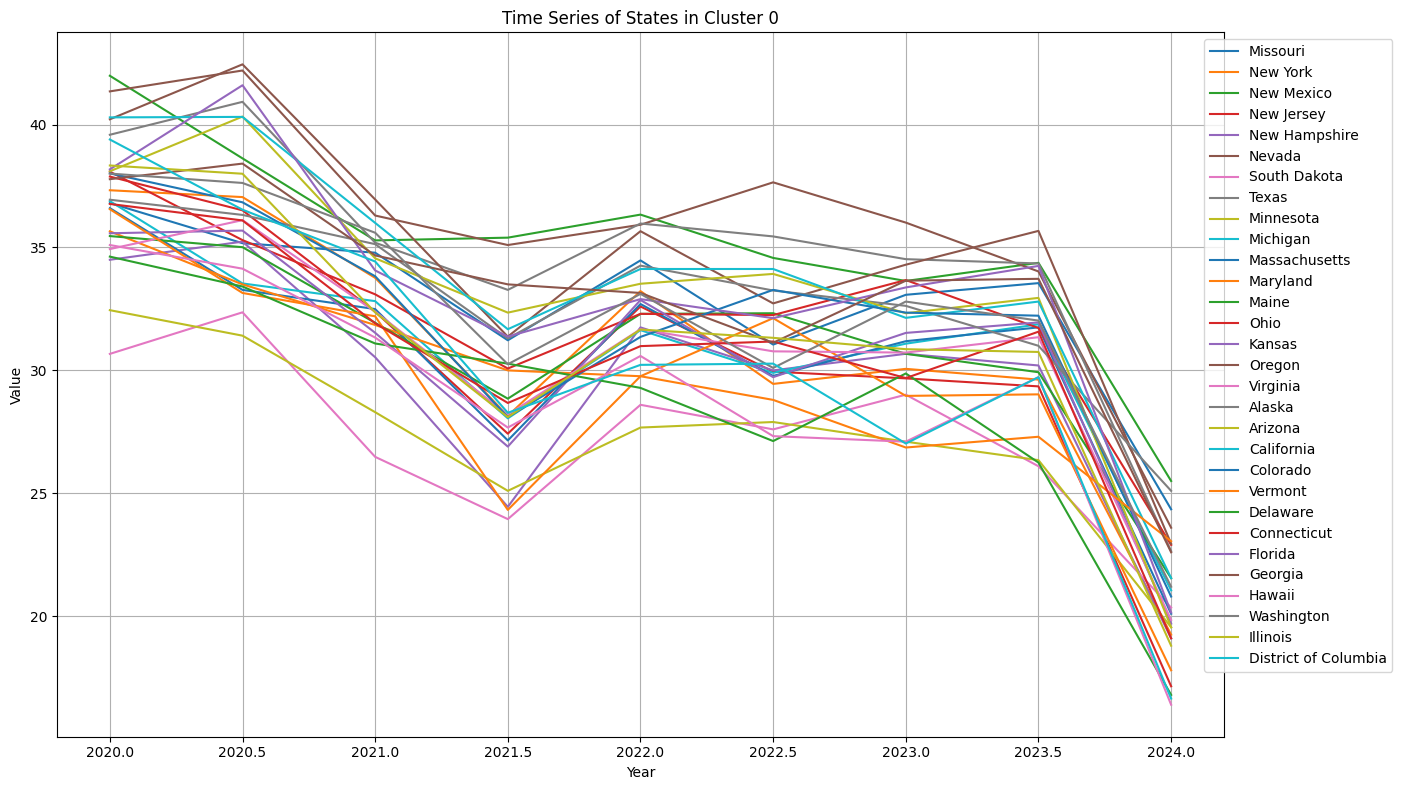

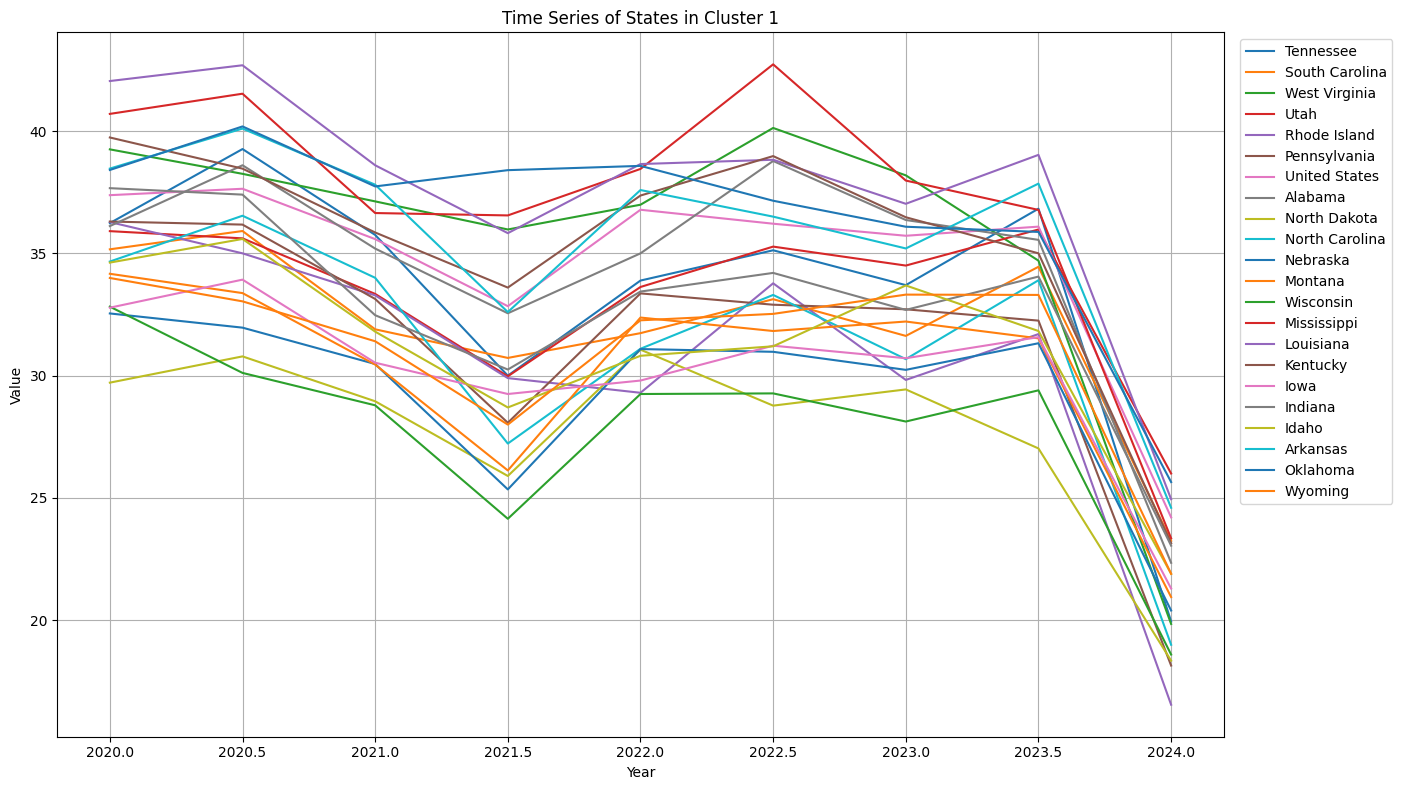

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('States in Each Cluster', fontsize=16)

# Define column and row configurations
columns = [f'Cluster {i}' for i in range(optimal_clusters)]
rows = max(len(cluster) for cluster in clusters)

# Create table with state names
table_data = []
for i in range(rows):
    row = []
    for cluster in clusters:
        if i < len(cluster):
            row.append(cluster[i])
        else:
            row.append("")
    table_data.append(row)

# Plot the table
table = plt.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Hide axes
ax.axis('off')
plt.show()

# Plot the time series for each cluster
for cluster_num in range(optimal_clusters):
    plt.figure(figsize=(14, 8))
    cluster_states = clusters[cluster_num]
    for state in cluster_states:
        plt.plot(state_time_series.columns[:-1], state_time_series.loc[state].values[:-1], label=state)
    plt.title(f'Time Series of States in Cluster {cluster_num}')
    plt.xlabel('Year')
    plt.ylabel('Value')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/3336748742.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.fr

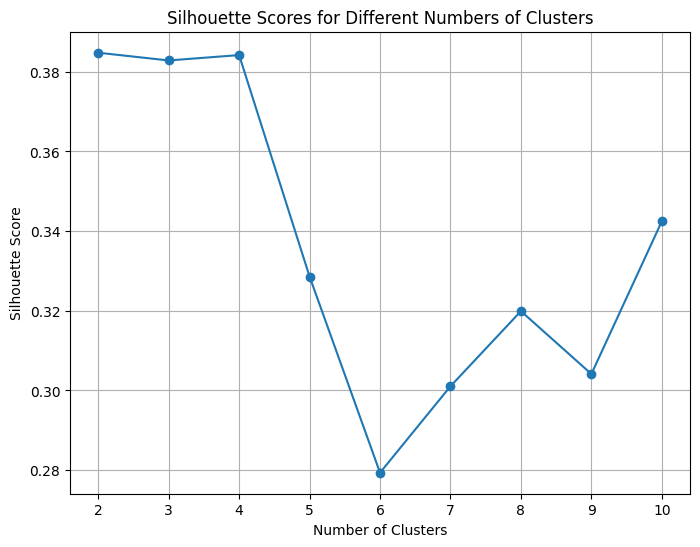

Silhoutte Scores: [0.384792848651284, 0.3828502060997395, 0.38420105480694483, 0.3285888757239887, 0.27932804072994316, 0.3010387203977937, 0.3199042258274919, 0.30411455604245075, 0.3424718545675987]
Optimal number of clusters: 4


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


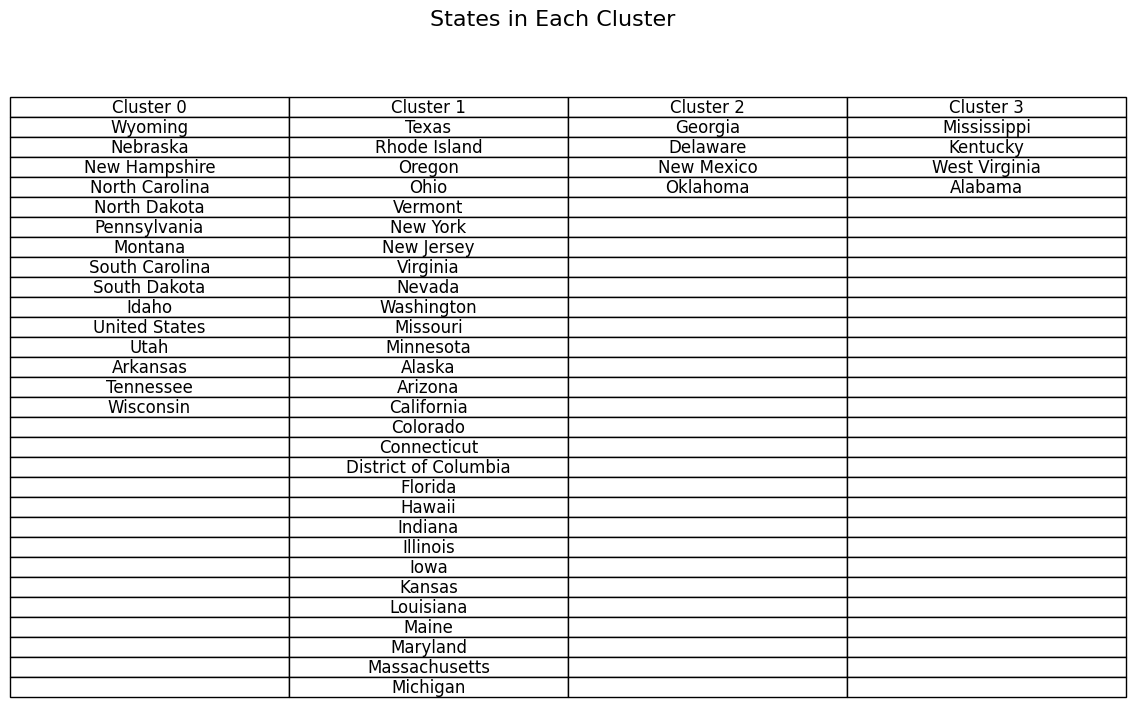

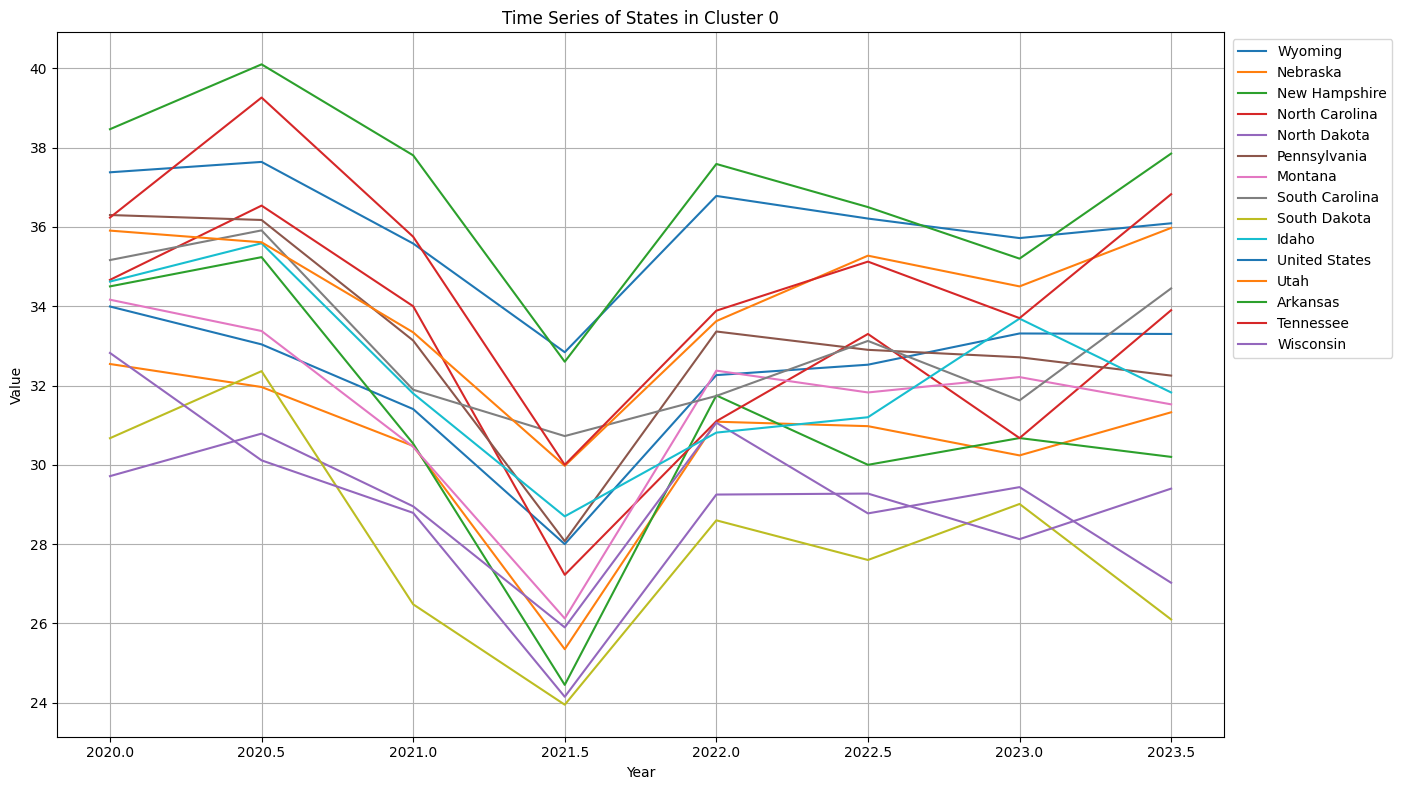

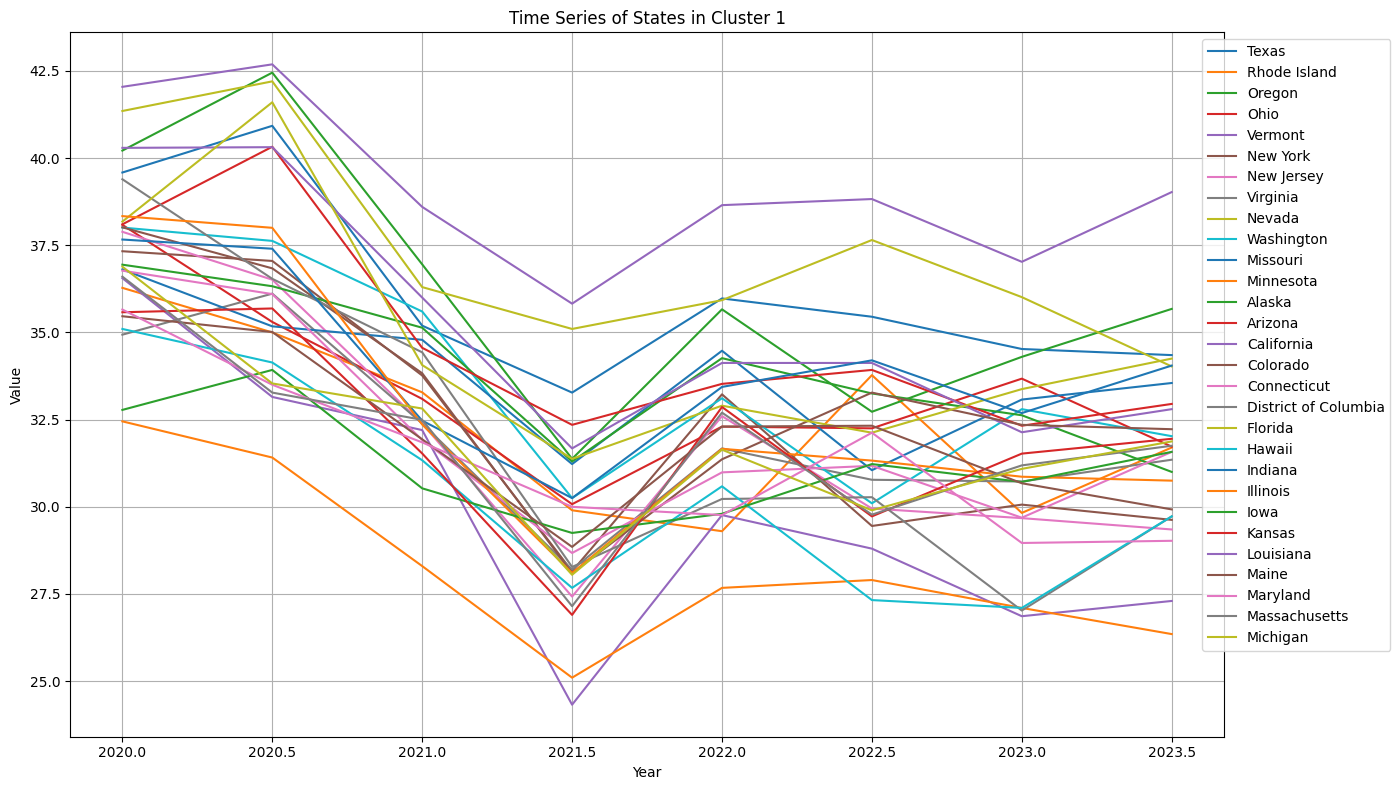

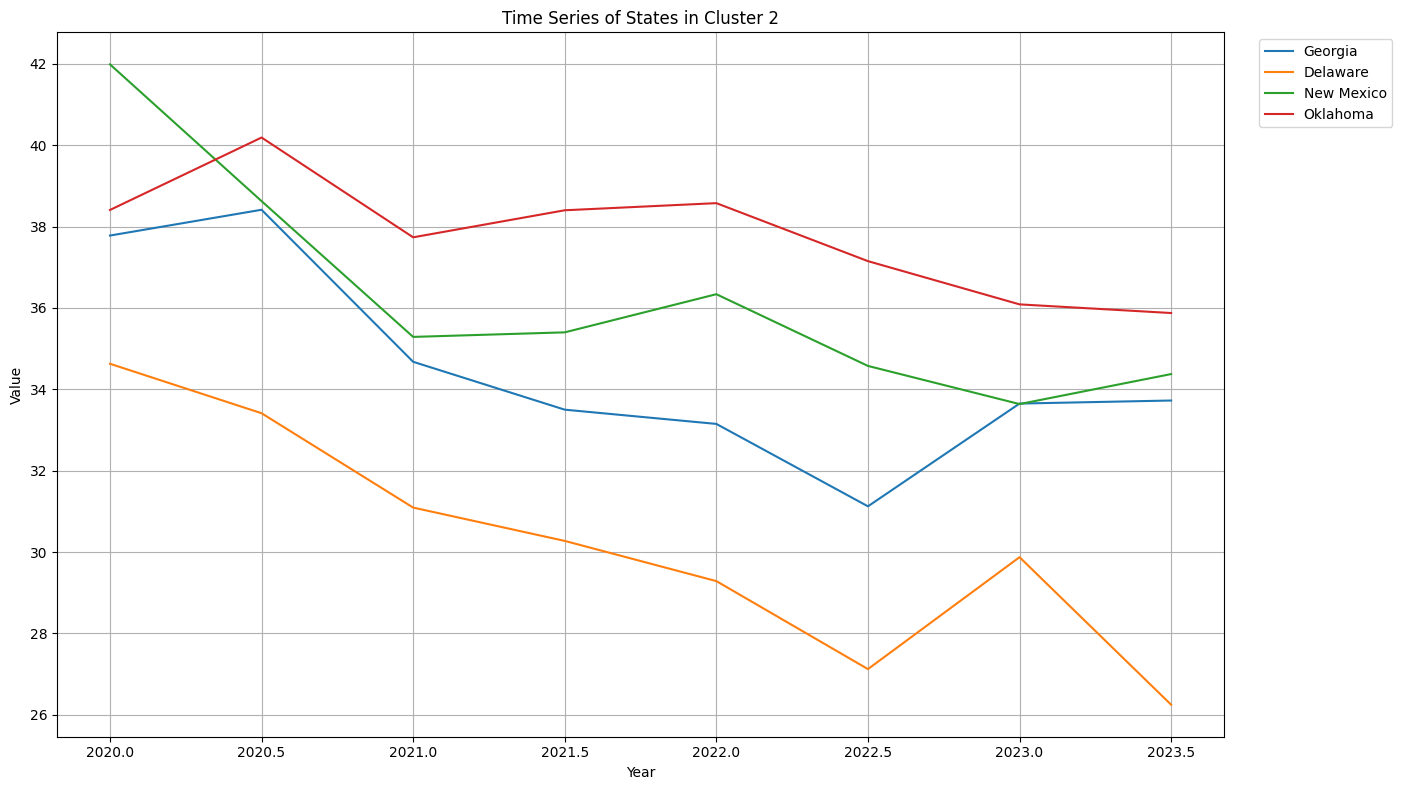

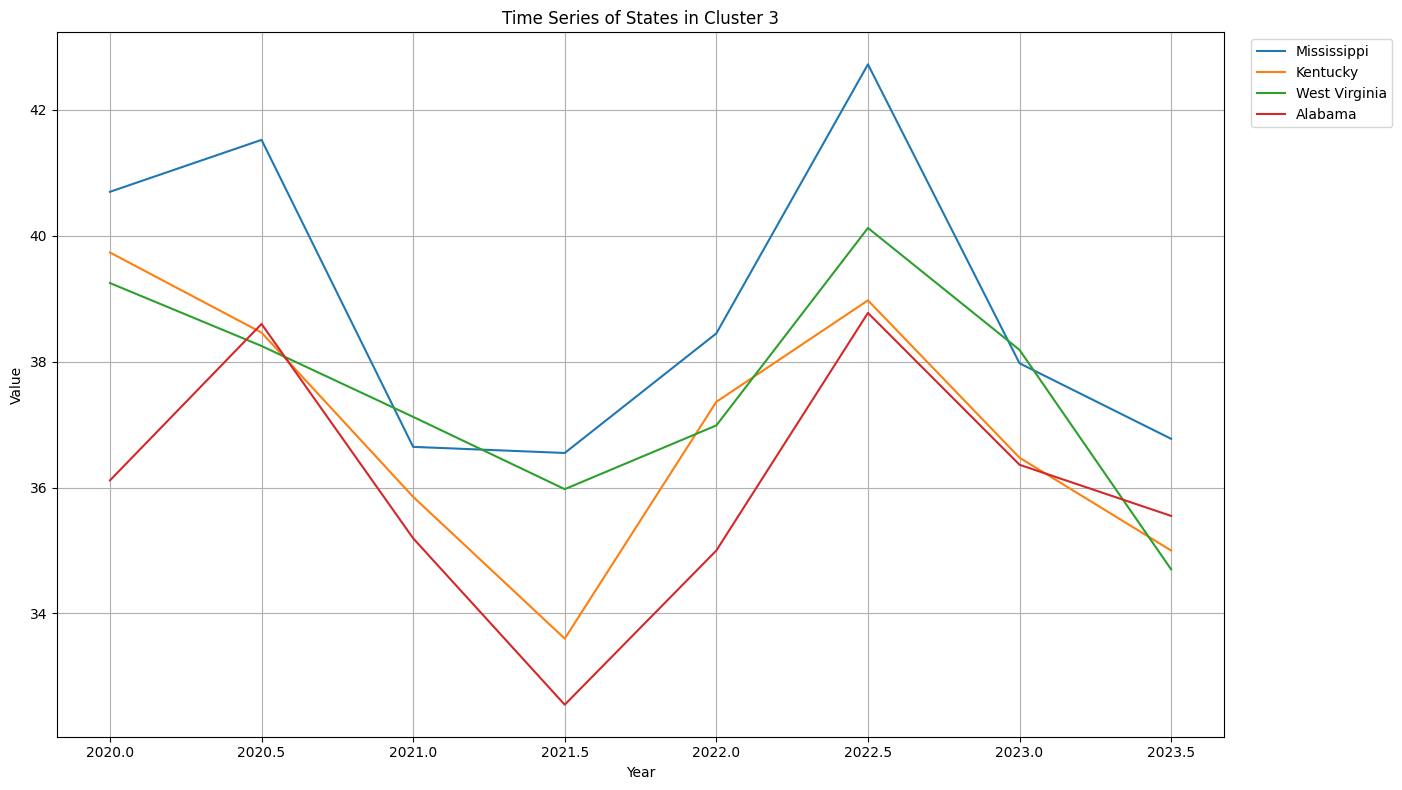

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year and month from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year
filtered_data['Month'] = filtered_data['Time Period Start Date'].dt.month

# Exclude data from 2024
filtered_data = filtered_data[filtered_data['Year'] < 2024]

filtered_data.head()

# Filter for June (6) and July (7)
mid_year_data = filtered_data[filtered_data['Month'].isin([6, 7])]

# Ensure we have data for each state and mid-year month (June or July)
mid_year_data = mid_year_data.groupby(['State', 'Year']).first().reset_index()

# Combine mid-year data with the original full-year data
combined_data = pd.concat([filtered_data, mid_year_data], ignore_index=True)

# Update the 'Year' column to include mid-year points
combined_data['Year'] = combined_data.apply(
    lambda row: row['Year'] + 0.5 if row['Month'] in [6, 7] else row['Year'], axis=1
)

combined_data.head()


# Pivot the data to get states as rows and years (including mid-years) as columns
state_time_series = combined_data.pivot_table(index='State', columns='Year', values='Value')

# Sort the columns to ensure the mid-year points are in the correct order
state_time_series = state_time_series.reindex(sorted(state_time_series.columns), axis=1)

state_time_series.head()


# Calculate the Pearson correlation coefficient and convert it to a distance metric
correlation_matrix = state_time_series.T.corr()
distance_matrix = 1 - correlation_matrix

# Convert the distance matrix to a set of features using MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
features = mds.fit_transform(distance_matrix)

# Determine the optimal number of clusters using the silhouette score
silhouette_scores = []
for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, random_state=0)
    labels = kmeans.fit_predict(features)
    silhouette_scores.append(silhouette_score(features, labels))

# Plot the silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Choose the optimal number of clusters based on the highest silhouette score
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 4
print(f'Silhoutte Scores: {silhouette_scores}')
print(f'Optimal number of clusters: {optimal_clusters}')

# Apply K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0)
clusters = kmeans.fit_predict(features)
state_time_series['Cluster'] = clusters

# Create a DataFrame to display states in each cluster
clustered_states = state_time_series[['Cluster']].reset_index()
clustered_states = clustered_states.sort_values('Cluster')

# Display states in each cluster as a list
clusters = []
for cluster in range(optimal_clusters):
    states_in_cluster = clustered_states[clustered_states['Cluster'] == cluster]['State'].tolist()
    clusters.append(states_in_cluster)

# Plot the clusters as text lists in a table format
fig, ax

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('States in Each Cluster', fontsize=16)

# Define column and row configurations
columns = [f'Cluster {i}' for i in range(optimal_clusters)]
rows = max(len(cluster) for cluster in clusters)

# Create table with state names
table_data = []
for i in range(rows):
    row = []
    for cluster in clusters:
        if i < len(cluster):
            row.append(cluster[i])
        else:
            row.append("")
    table_data.append(row)

# Plot the table
table = plt.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Hide axes
ax.axis('off')
plt.show()

# Plot the time series for each cluster
for cluster_num in range(optimal_clusters):
    plt.figure(figsize=(14, 8))
    cluster_states = clusters[cluster_num]
    for state in cluster_states:
        plt.plot(state_time_series.columns[:-1], state_time_series.loc[state].values[:-1], label=state)
    plt.title(f'Time Series of States in Cluster {cluster_num}')
    plt.xlabel('Year')
    plt.ylabel('Value')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [44]:
import pandas as pd

# Load the CSV file
file_path = 'Depression_Symptoms.csv'  # Update the path if necessary
depression_data = pd.read_csv(file_path)

# Filter data for "Symptoms of Anxiety Disorder or Depressive Disorder"
filtered_data = depression_data[
    depression_data['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder'
]

# Drop rows with missing values in the 'Value' column
filtered_data = filtered_data.dropna(subset=['Value'])

# Convert 'Time Period Start Date' to datetime
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])

# Extract year and month from 'Time Period Start Date'
filtered_data['Year'] = filtered_data['Time Period Start Date'].dt.year
filtered_data['Month'] = filtered_data['Time Period Start Date'].dt.month

# Exclude data from 2024
filtered_data = filtered_data[filtered_data['Year'] < 2024]

filtered_data.head()


/var/folders/p2/rz1lhyd55yl46nyg46nrzshh0000gn/T/ipykernel_22593/276665616.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range,Year,Month
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.9,35.0,36.8,35.0 - 36.8,NaN,2020,4
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,46.8,44.3,49.3,44.3 - 49.3,NaN,2020,4
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,39.6,37.7,41.5,37.7 - 41.5,NaN,2020,4
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,38.9,37.2,40.7,37.2 - 40.7,NaN,2020,4
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.8,34.0,37.7,34.0 - 37.7,NaN,2020,4


In [45]:
# Create a unique time index based on Year and Month
filtered_data['YearMonth'] = filtered_data['Year'] + (filtered_data['Month'] - 1) / 12

# Combine monthly data with the original data
combined_data = filtered_data.copy()

combined_data.head()


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range,Year,Month,YearMonth
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.9,35.0,36.8,35.0 - 36.8,NaN,2020,4,2020.25
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,46.8,44.3,49.3,44.3 - 49.3,NaN,2020,4,2020.25
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,39.6,37.7,41.5,37.7 - 41.5,NaN,2020,4,2020.25
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,38.9,37.2,40.7,37.2 - 40.7,NaN,2020,4,2020.25
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",2020-04-23,5/5/20,35.8,34.0,37.7,34.0 - 37.7,NaN,2020,4,2020.25


In [46]:
# Pivot the data to get states as rows and YearMonth as columns
state_time_series = combined_data.pivot_table(index='State', columns='YearMonth', values='Value')

# Sort the columns to ensure the monthly points are in the correct order
state_time_series = state_time_series.reindex(sorted(state_time_series.columns), axis=1)

state_time_series.head()


YearMonth,2020.250000,2020.333333,2020.416667,2020.500000,2020.583333,2020.666667,2020.750000,2020.833333,2020.916667,2021.000000,...,2022.916667,2023.000000,2023.083333,2023.166667,2023.250000,2023.416667,2023.500000,2023.583333,2023.666667,2023.750000
State,,,,,,,,,,,,,,,,,,,,,
Alabama,30.3,30.525,37.225,41.000000,37.2,36.300000,40.40,41.15,44.0,42.70,...,36.9,38.2,34.7,37.80,37.9,36.00,35.1,30.4,38.2,35.9
Alaska,31.5,34.100,36.025,37.100000,34.8,35.500000,38.35,43.60,44.1,42.30,...,35.4,31.6,32.2,33.80,29.1,28.80,34.8,28.1,36.0,36.4
Arizona,36.4,34.650,38.575,43.833333,35.1,38.700000,40.05,41.80,43.5,39.60,...,31.1,33.2,35.8,31.70,30.4,32.00,34.1,30.0,30.6,35.2
Arkansas,38.0,35.250,38.200,43.266667,35.3,38.333333,40.05,43.05,43.0,40.55,...,37.0,30.6,32.6,37.90,35.3,36.30,39.4,34.2,37.5,35.6
California,37.4,37.000,38.700,42.666667,38.0,41.266667,41.80,44.15,45.0,45.75,...,33.0,32.6,31.7,31.45,33.9,32.55,34.4,28.5,33.5,34.0


In [47]:
from scipy.spatial.distance import pdist, squareform

# Calculate the Pearson correlation coefficient and convert it to a distance metric
correlation_matrix = state_time_series.T.corr()
distance_matrix = 1 - correlation_matrix

distance_matrix.head()


State,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,District of Columbia,Florida,...,Tennessee,Texas,United States,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
State,,,,,,,,,,,,,,,,,,,,,
Alabama,0.000000,0.248633,0.420321,0.501174,0.359507,0.316047,0.507921,0.484805,0.619598,0.388442,...,0.313358,0.314733,0.227804,0.381188,0.461336,0.354119,0.475809,0.344454,0.305977,0.361139
Alaska,0.248633,0.000000,0.268151,0.295322,0.200656,0.221646,0.322358,0.285045,0.388664,0.306465,...,0.314030,0.202891,0.144764,0.342478,0.229398,0.186037,0.224886,0.296804,0.208524,0.334866
Arizona,0.420321,0.268151,0.000000,0.261173,0.144474,0.168144,0.173904,0.246630,0.313667,0.245487,...,0.220553,0.155237,0.223785,0.391682,0.260264,0.198736,0.179967,0.485206,0.197779,0.485258
Arkansas,0.501174,0.295322,0.261173,0.000000,0.312919,0.227264,0.397744,0.455096,0.582084,0.382719,...,0.358421,0.374705,0.236712,0.468816,0.364752,0.310951,0.345318,0.520396,0.267493,0.370265
California,0.359507,0.200656,0.144474,0.312919,0.000000,0.137569,0.135137,0.319246,0.252306,0.183797,...,0.250657,0.138128,0.219013,0.359320,0.146727,0.150120,0.115972,0.422225,0.127150,0.417762


In [48]:
from sklearn.manifold import MDS

# Convert the distance matrix to a set of features using MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
features = mds.fit_transform(distance_matrix)

features[:5]

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


array([[ 0.32698522,  0.05737874],
       [ 0.04455433, -0.12130384],
       [-0.02294311,  0.11966864],
       [-0.14140082, -0.23813903],
       [-0.07987977,  0.06411503]])

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-p

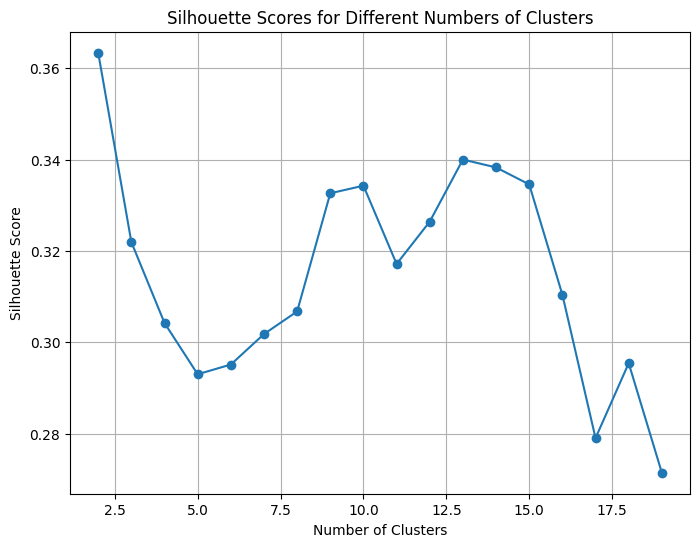

Optimal number of clusters: 13


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


YearMonth,2020.25,2020.3333333333333,2020.4166666666667,2020.5,2020.5833333333333,2020.6666666666667,2020.75,2020.8333333333333,2020.9166666666667,2021.0,...,2023.0,2023.0833333333333,2023.1666666666667,2023.25,2023.4166666666667,2023.5,2023.5833333333333,2023.6666666666667,2023.75,Cluster
State,,,,,,,,,,,,,,,,,,,,,
Alabama,30.3,30.525,37.225,41.000000,37.2,36.300000,40.40,41.15,44.0,42.70,...,38.2,34.7,37.80,37.9,36.00,35.1,30.4,38.2,35.9,4
Alaska,31.5,34.100,36.025,37.100000,34.8,35.500000,38.35,43.60,44.1,42.30,...,31.6,32.2,33.80,29.1,28.80,34.8,28.1,36.0,36.4,11
Arizona,36.4,34.650,38.575,43.833333,35.1,38.700000,40.05,41.80,43.5,39.60,...,33.2,35.8,31.70,30.4,32.00,34.1,30.0,30.6,35.2,8
Arkansas,38.0,35.250,38.200,43.266667,35.3,38.333333,40.05,43.05,43.0,40.55,...,30.6,32.6,37.90,35.3,36.30,39.4,34.2,37.5,35.6,3
California,37.4,37.000,38.700,42.666667,38.0,41.266667,41.80,44.15,45.0,45.75,...,32.6,31.7,31.45,33.9,32.55,34.4,28.5,33.5,34.0,6


In [69]:
from sklearn.metrics import silhouette_score

# Determine the optimal number of clusters using the silhouette score
silhouette_scores = []
for n in range(2, 20):
    kmeans = KMeans(n_clusters=n, random_state=0)
    labels = kmeans.fit_predict(features)
    silhouette_scores.append(silhouette_score(features, labels))

# Plot the silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(range(2, 20), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Choose the optimal number of clusters based on the highest silhouette score
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 13
print(f'Optimal number of clusters: {optimal_clusters}')

# Apply K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0)
clusters = kmeans.fit_predict(features)
state_time_series['Cluster'] = clusters

state_time_series.head()


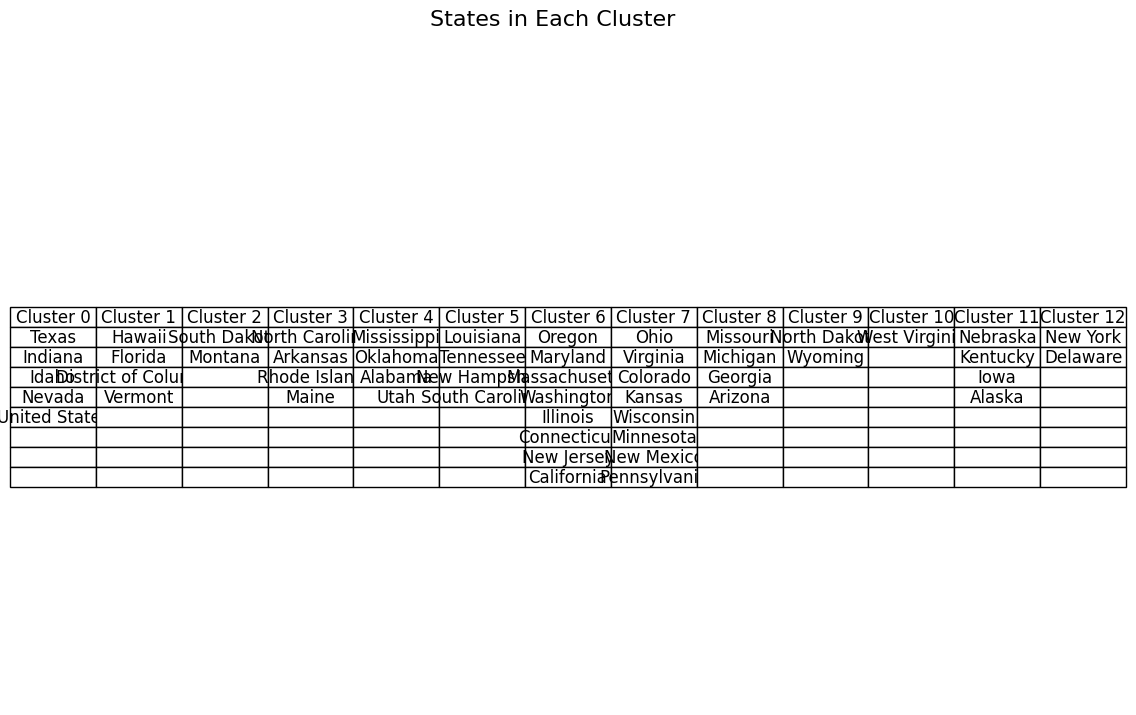

In [70]:
# Create a DataFrame to display states in each cluster
clustered_states = state_time_series[['Cluster']].reset_index()
clustered_states = clustered_states.sort_values('Cluster')

# Display states in each cluster as a list
clusters = []
for cluster in range(optimal_clusters):
    states_in_cluster = clustered_states[clustered_states['Cluster'] == cluster]['State'].tolist()
    clusters.append(states_in_cluster)

# Plot the clusters as text lists in a table format
fig, ax

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('States in Each Cluster', fontsize=16)

# Define column and row configurations
columns = [f'Cluster {i}' for i in range(optimal_clusters)]
rows = max(len(cluster) for cluster in clusters)

# Create table with state names
table_data = []
for i in range(rows):
    row = []
    for cluster in clusters:
        if i < len(cluster):
            row.append(cluster[i])
        else:
            row.append("")
    table_data.append(row)

# Plot the table
table = plt.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Hide axes
ax.axis('off')
plt.show()

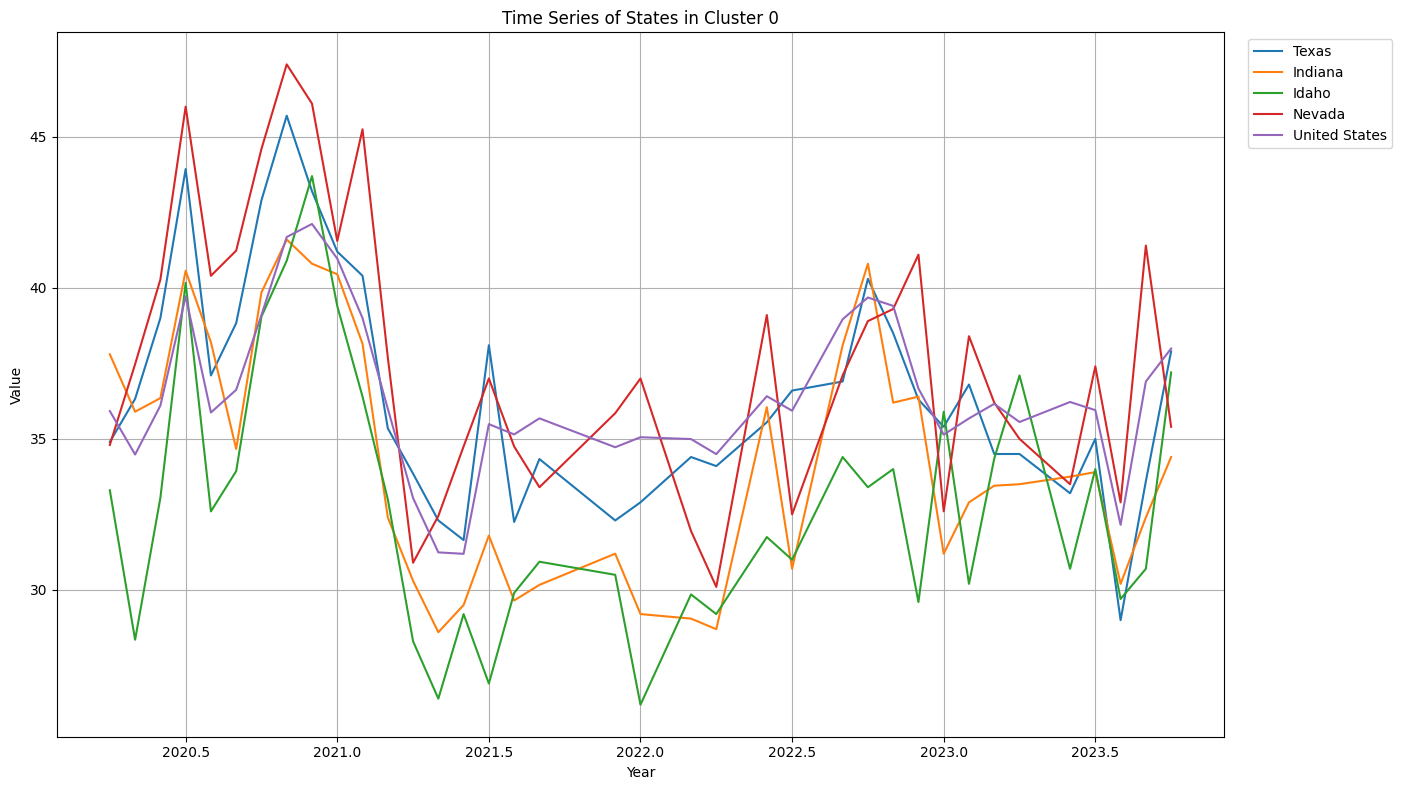

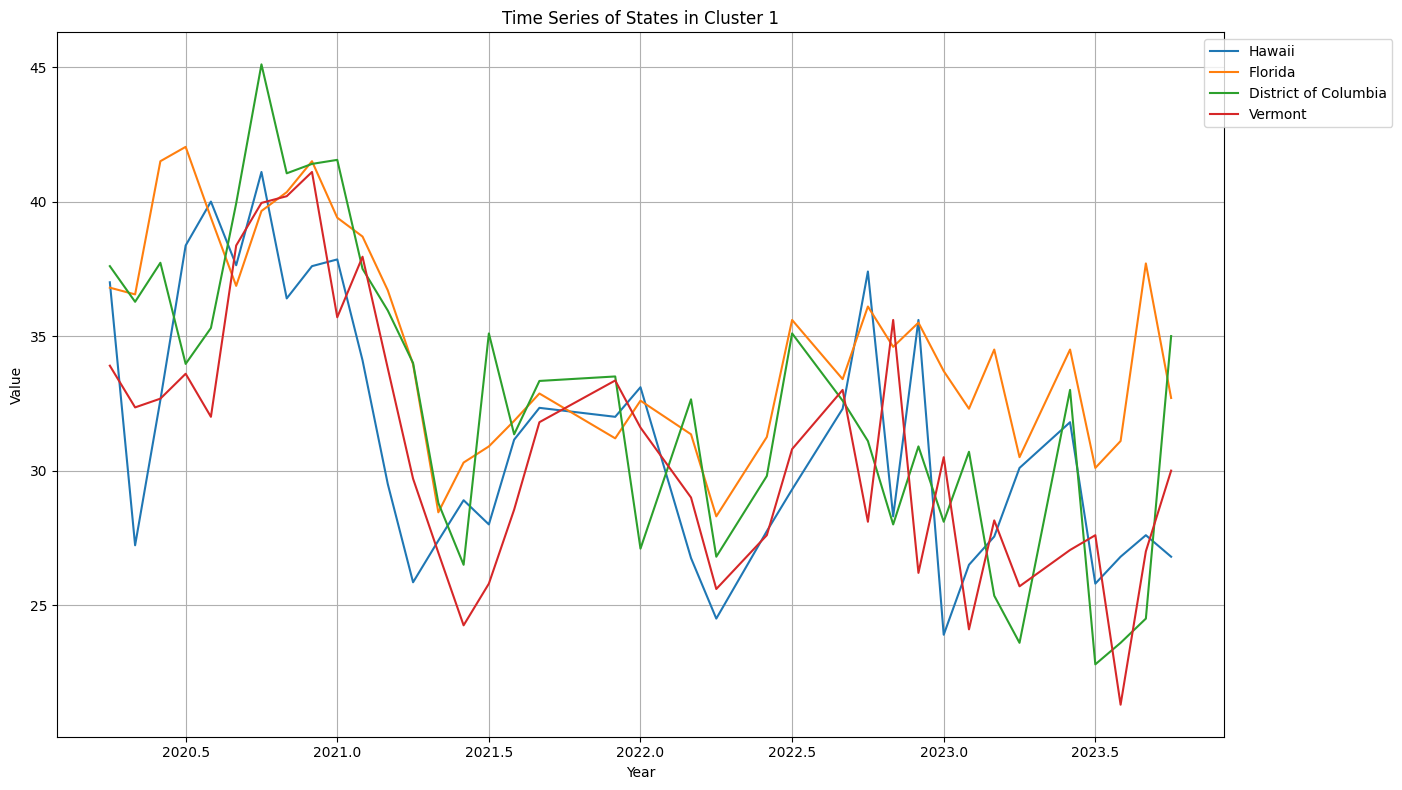

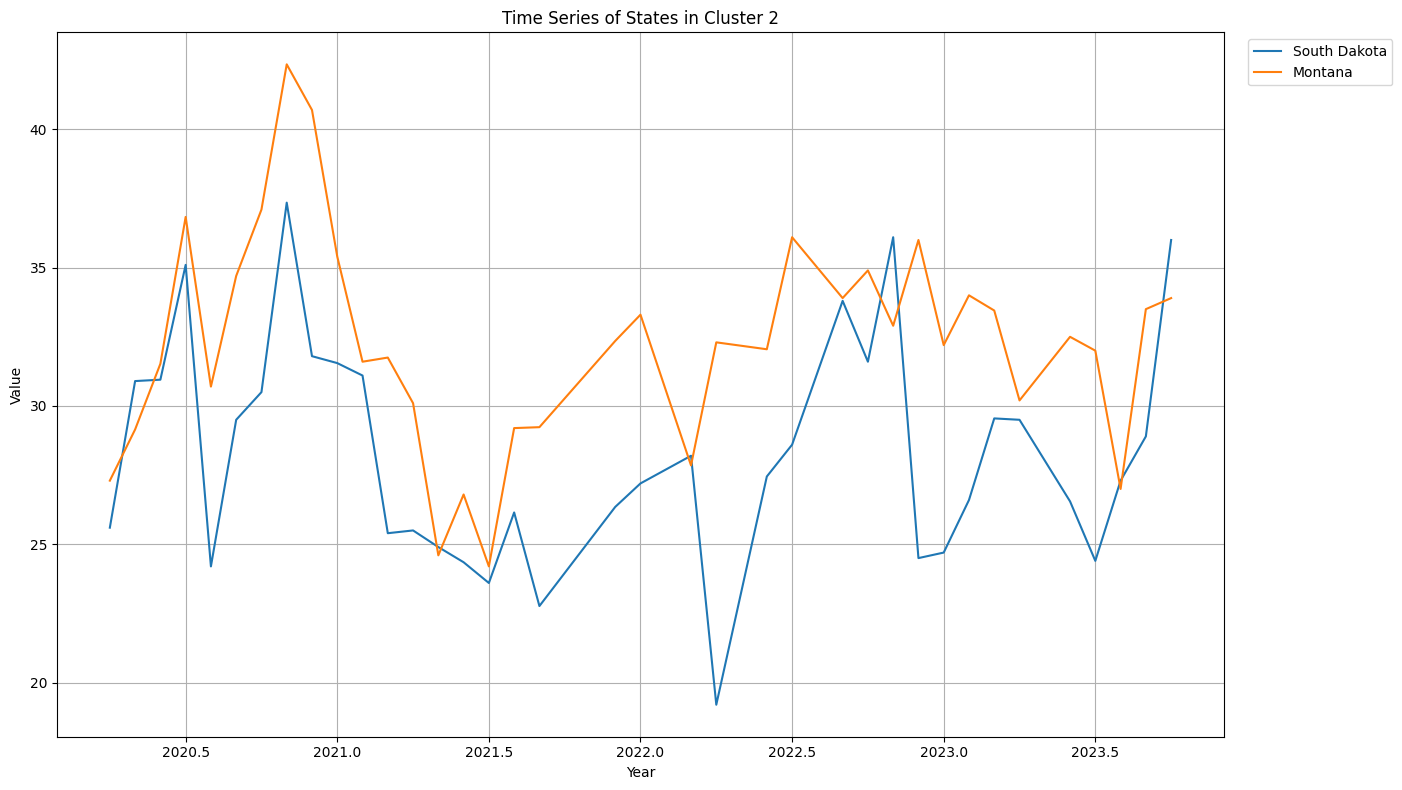

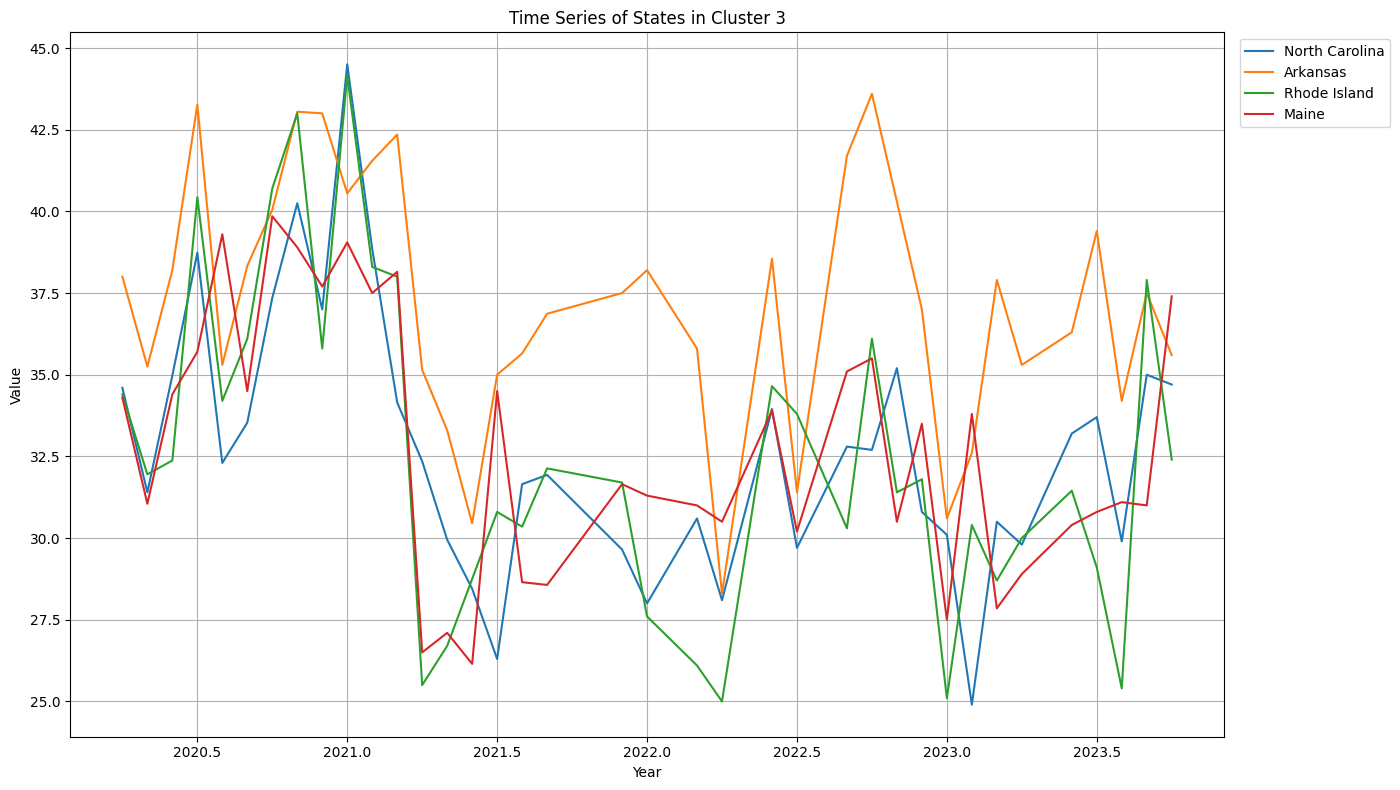

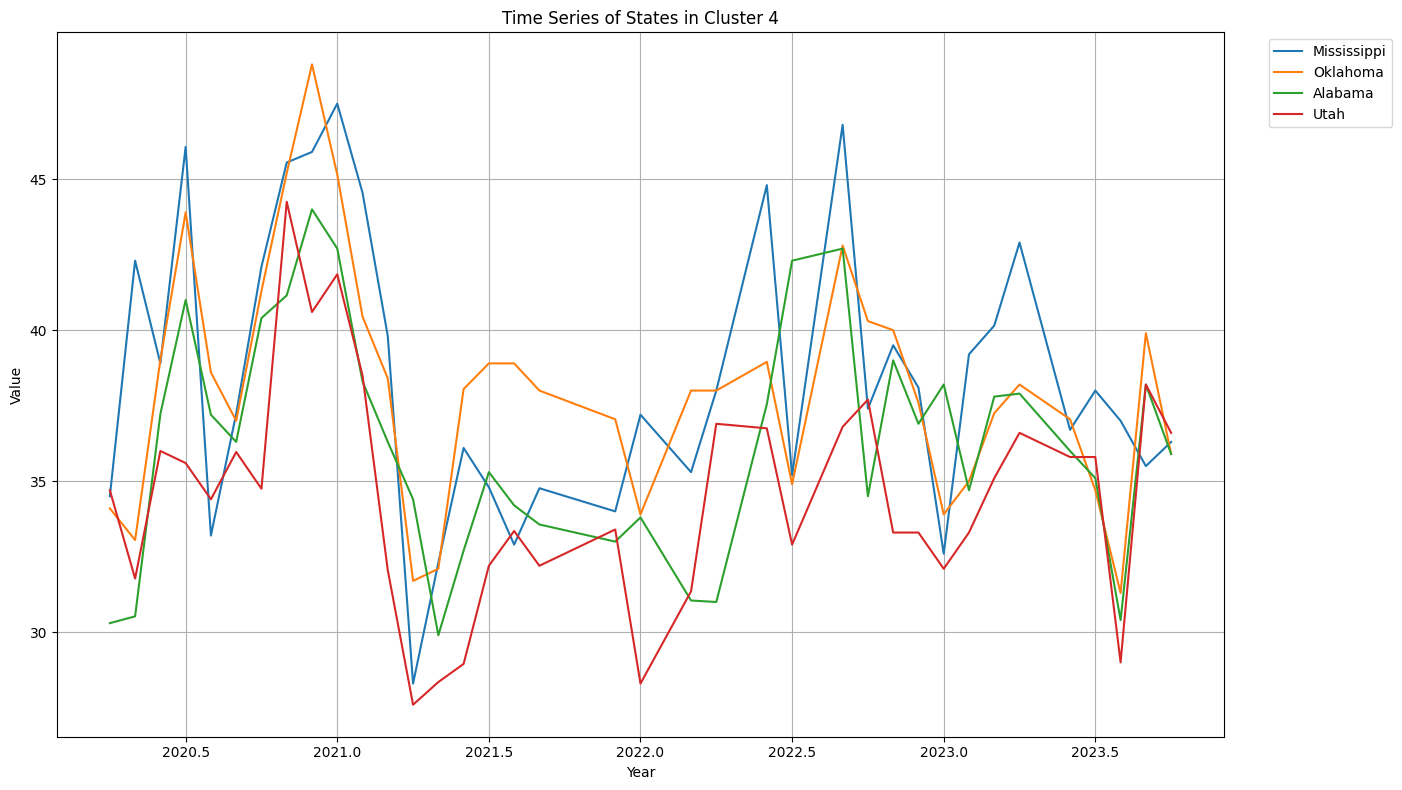

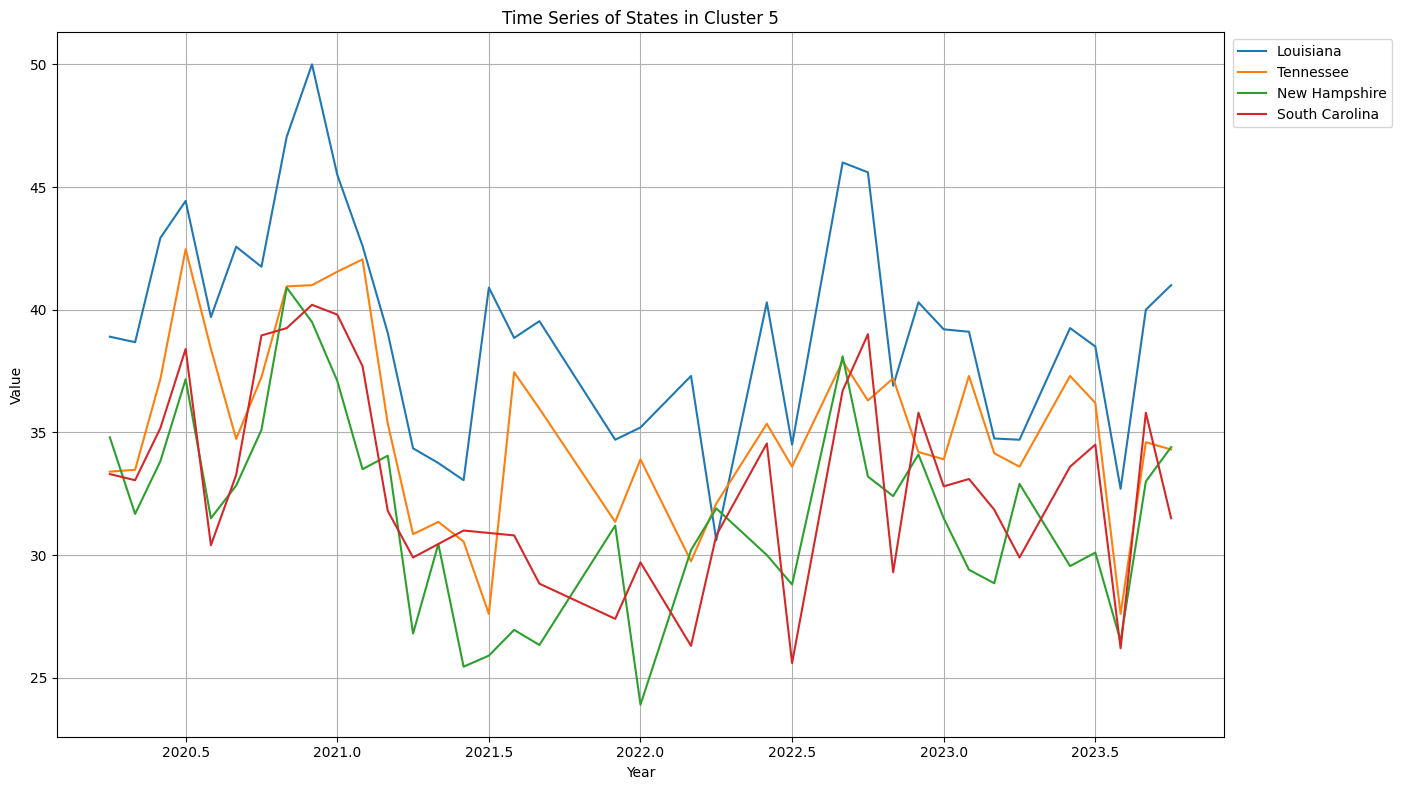

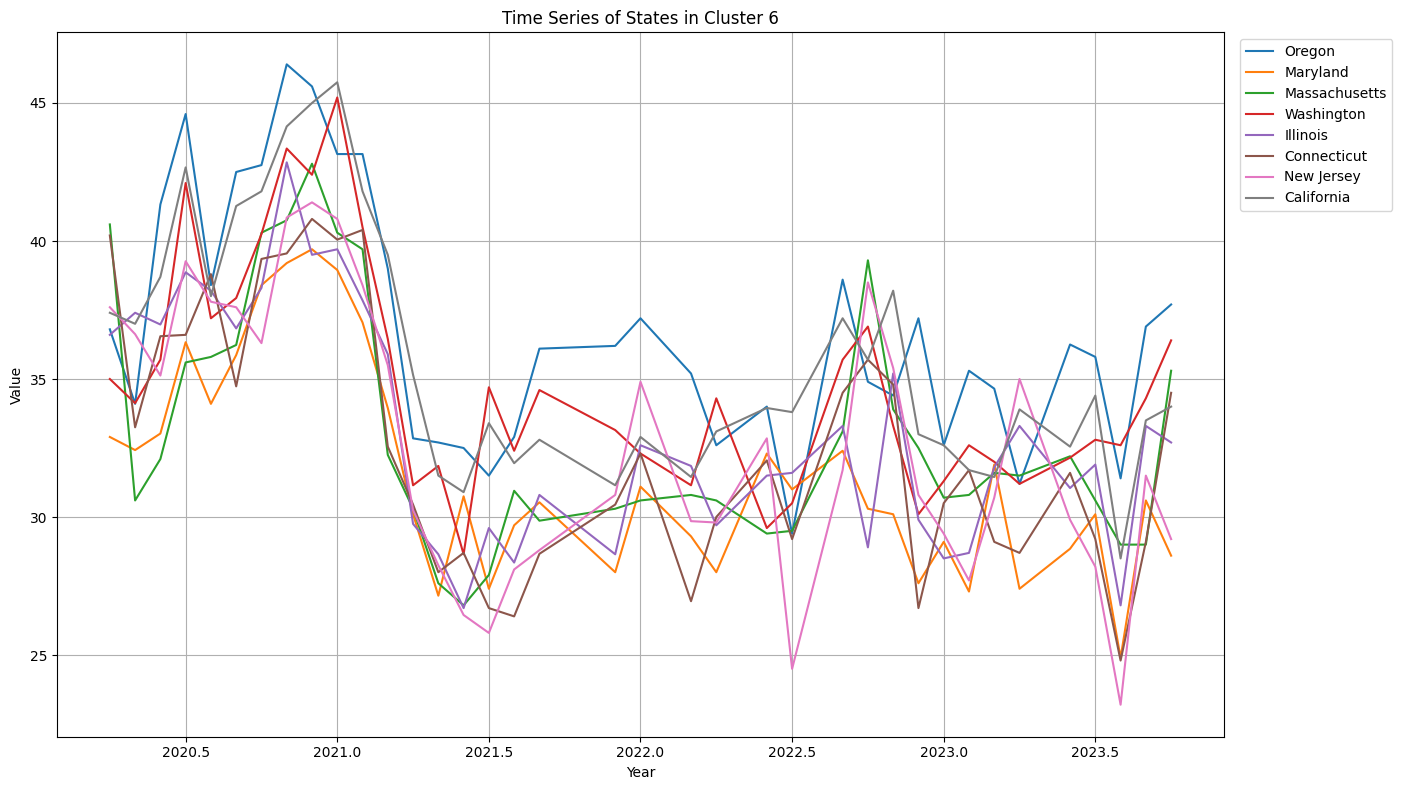

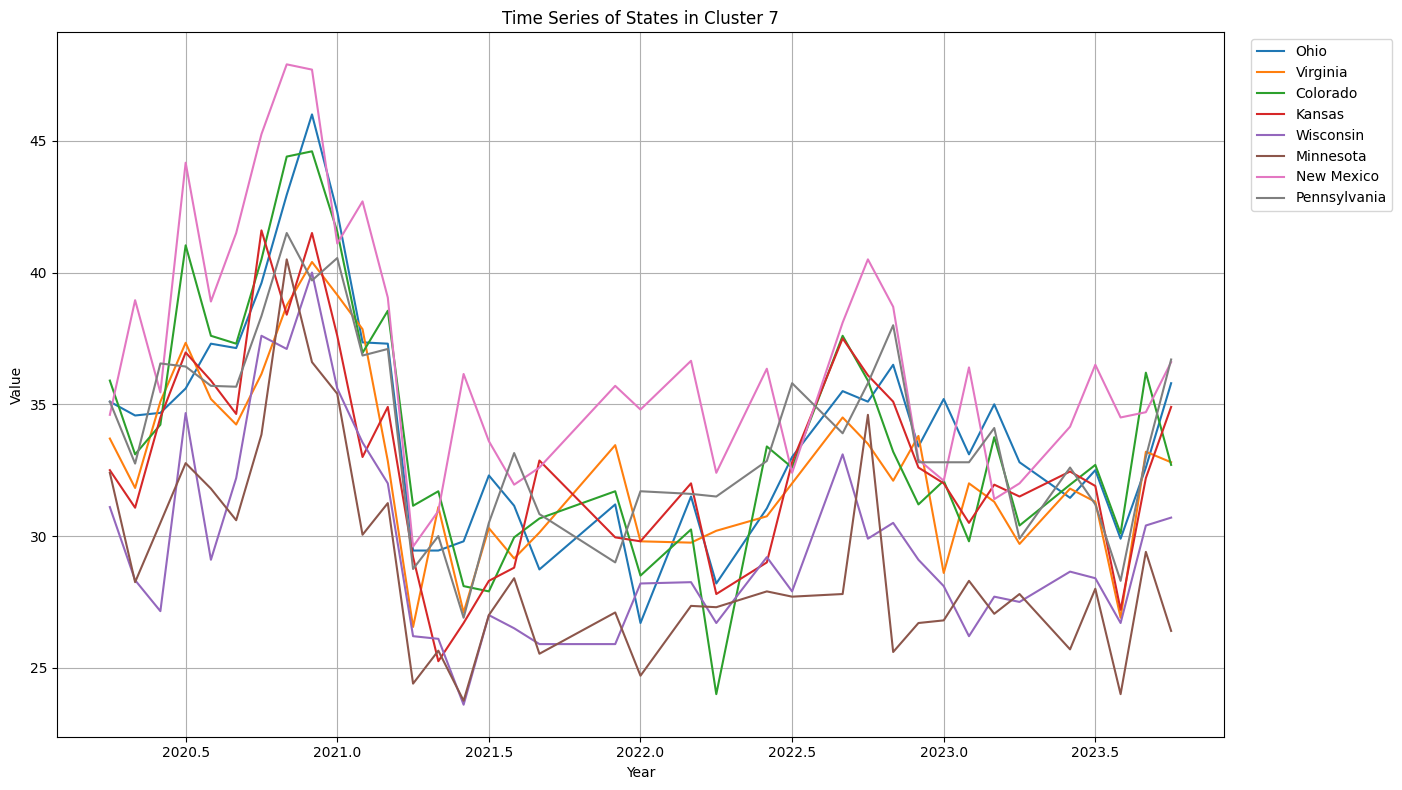

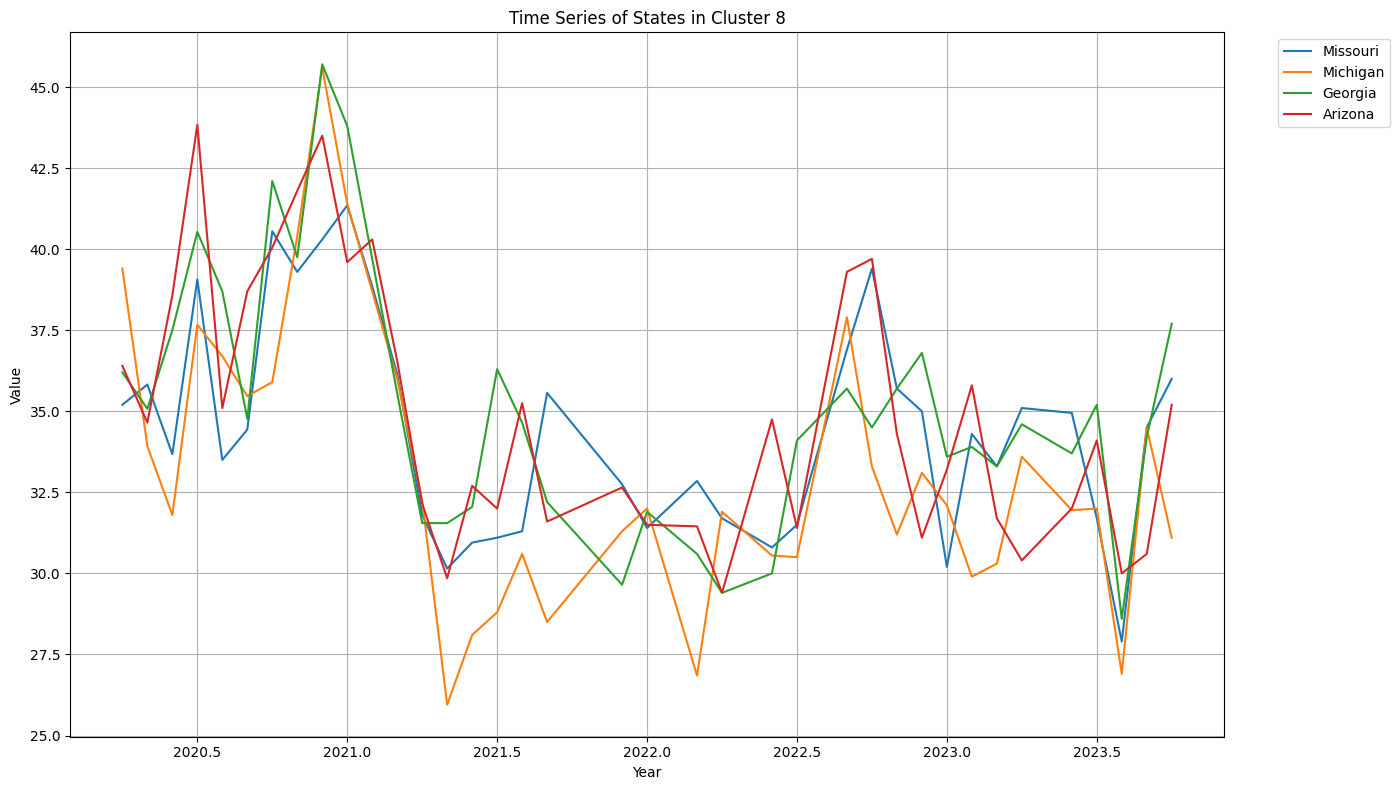

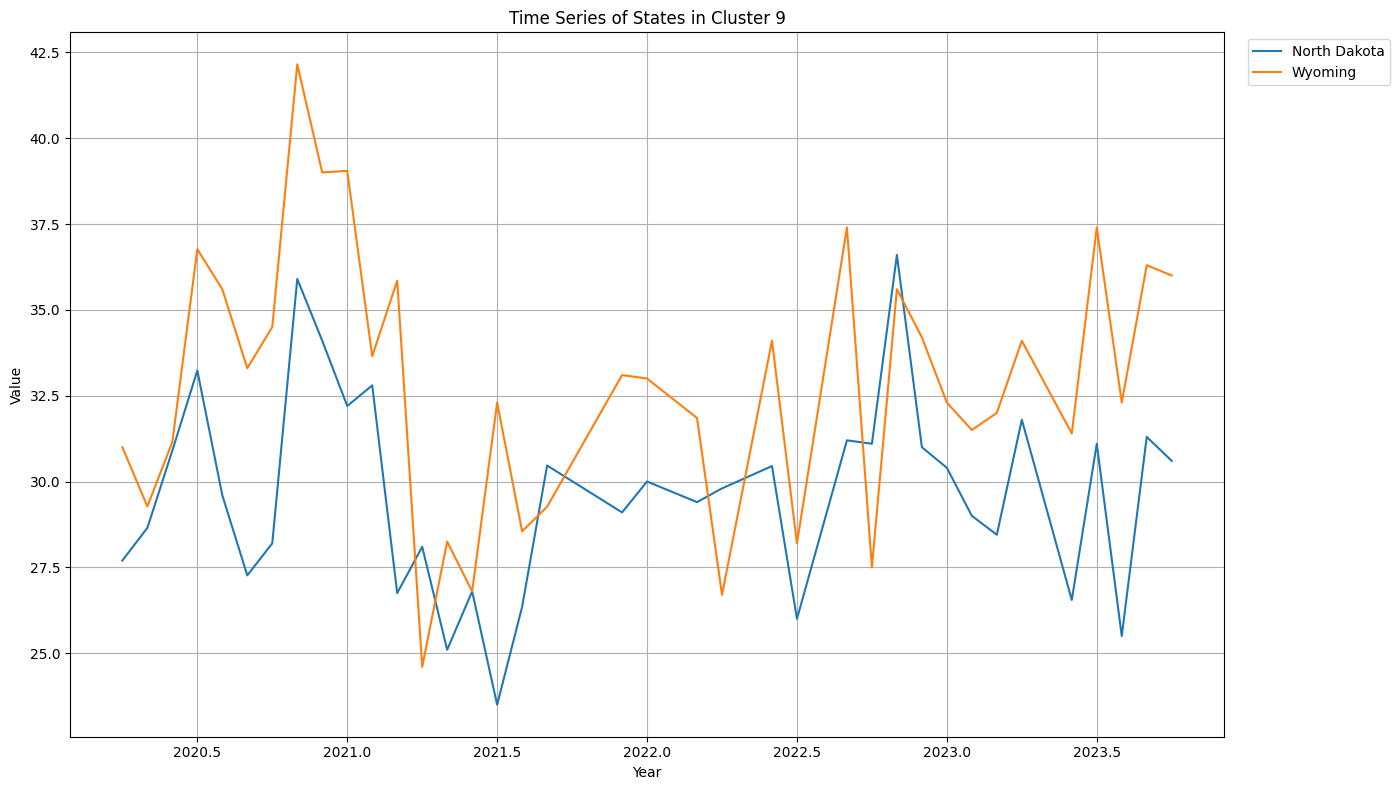

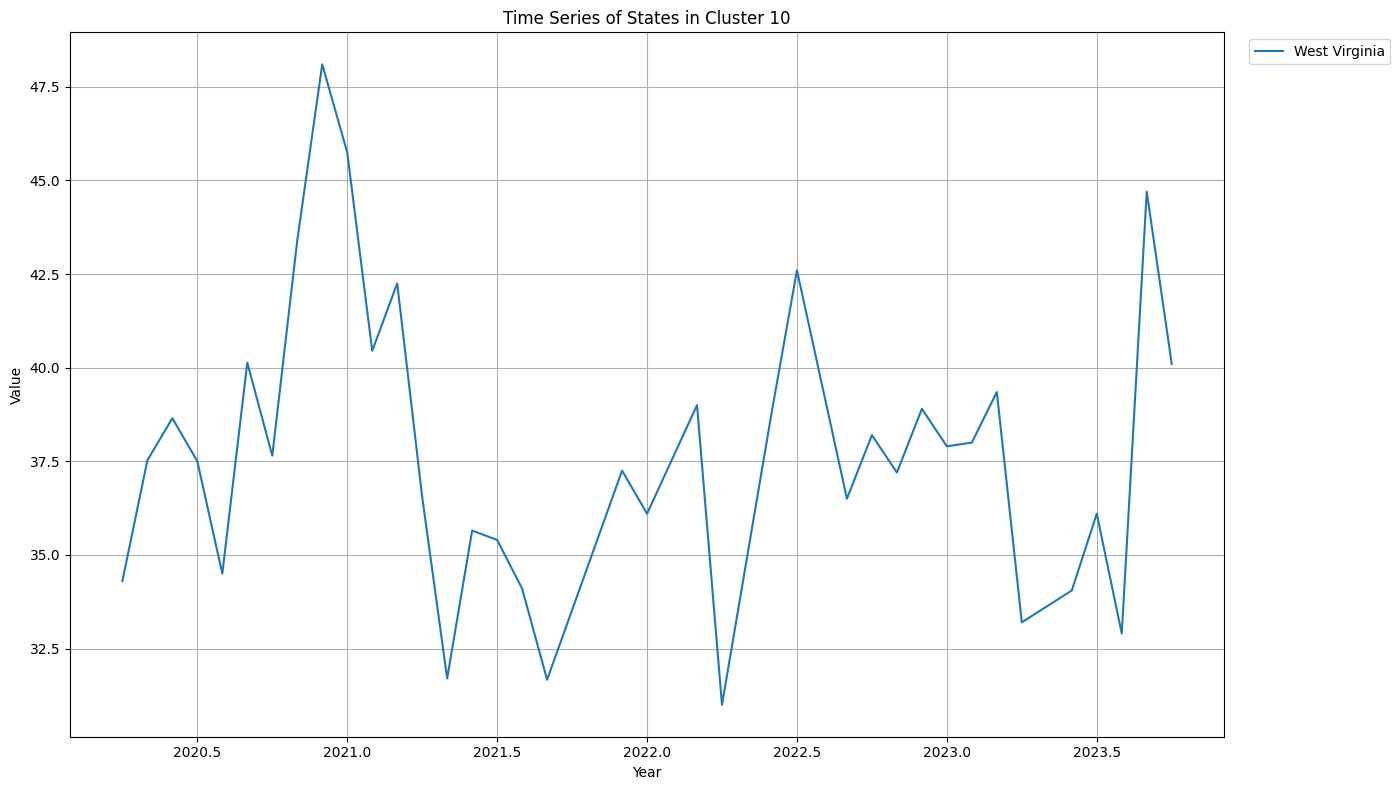

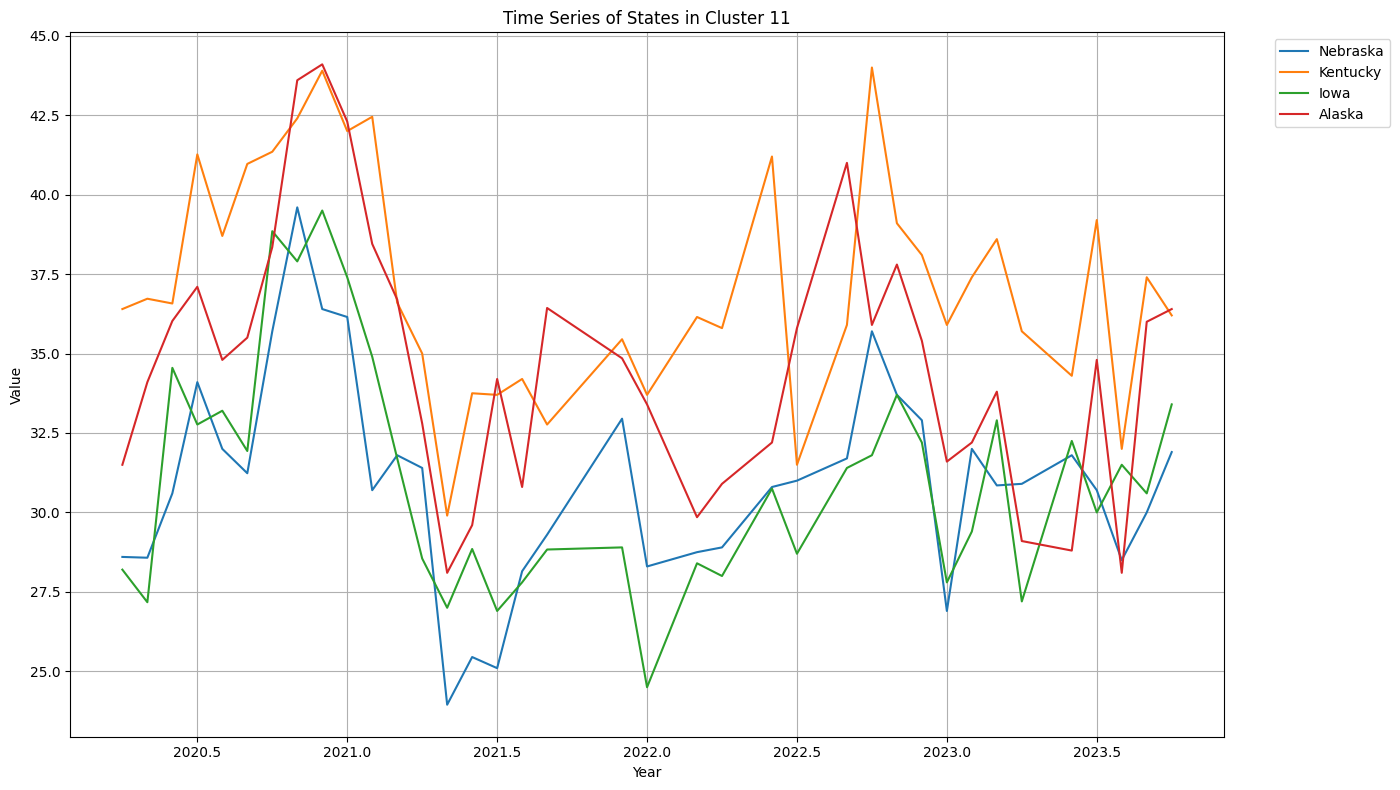

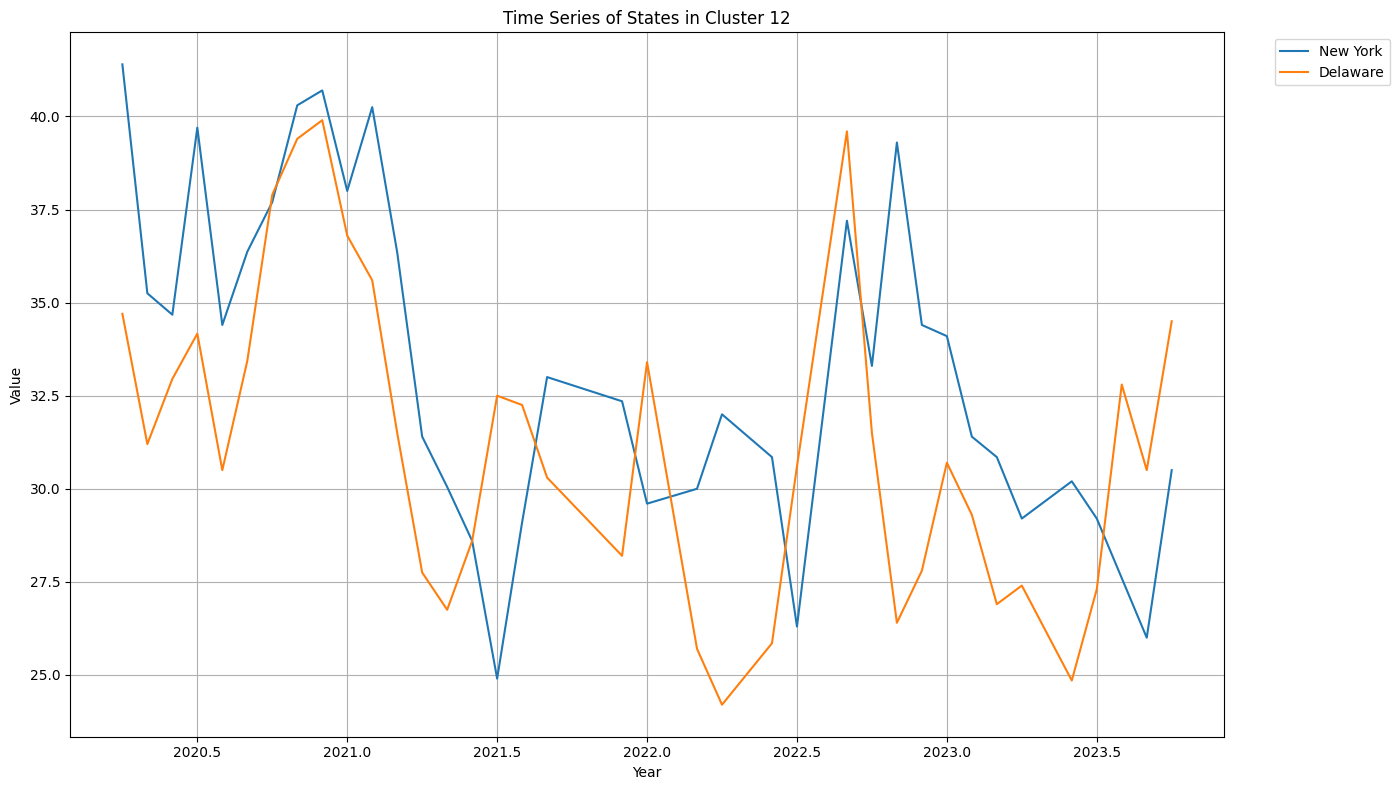

In [71]:
# Plot the time series for each cluster
for cluster_num in range(optimal_clusters):
    plt.figure(figsize=(14, 8))
    cluster_states = clusters[cluster_num]
    for state in cluster_states:
        plt.plot(state_time_series.columns[:-1], state_time_series.loc[state].values[:-1], label=state)
    plt.title(f'Time Series of States in Cluster {cluster_num}')
    plt.xlabel('Year')
    plt.ylabel('Value')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
